# Building a Model

How an expression is written in this package. Each section states one rule of
construction, shows it in code and asserts what it claims, so the notebook is the test
of the rules as well as their description. The rules for a whole published architecture
are in the vault's [Representing
Models](../../obsidian/06-practice/Representing%20Models.md), and [Construction
Helpers](../../obsidian/02-categories/Construction%20Helpers.md) explains the operator
overloads used throughout.

When a reviewer corrects how a model is expressed, add the correction to this notebook,
in the section it belongs to, with the rejected form beside its replacement. `CLAUDE.md`
states the same rule.

In [1]:
import torch

import construction_helpers as ch  # noqa: F401 - operator overloads
import construction_helpers.lift as lift
import data_structure.Category as cat
import data_structure.Numeric as nm
import data_structure.Operators as ops
import data_structure.Term as fd
import para.data_structure.Para as Para
import para.processing.show_grabbed_parameters as show_grabbed_parameters
import algebra.einops_simplification as einops_simplification
import algebra.operator_expansion as operator_expansion
import term_utilities.generate_config as generate_config
import term_utilities.term_utilities as tutil
import torch_compile.torch_compile as torch_compile

import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.display.notebook_listings as notebook_listings
import notebooks.display.tape_presentation as tape_presentation

# Notebook args
DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE)

R = cat.Reals()


async def show(term, caption, width=700):
    await notebook_diagrams.show_diagram(term, caption, width=width, settings=DIAGRAMS)


def claim(holds: bool, statement: str) -> None:
    if not holds:
        raise ValueError(f'the notebook claims that {statement}, and it does not hold')
    print(f'holds: {statement}')


def ranks(morphism) -> tuple[tuple[int, ...], tuple[int, ...]]:
    '''The rank of each array in the domain and in the codomain.'''
    return (tuple(len(array.shape()) for array in morphism.dom()),
            tuple(len(array.shape()) for array in morphism.cod()))

## 1. An operator becomes a morphism through `template`

A seed morphism is a `Broadcasted`. It carries an operator, one weave per input and per
output saying which positions the operator reads, and one reindexing per input saying
how the input's positions are indexed from the output's. `template` builds one from a
signature string. Each letter in the string is a fresh axis. A letter that appears in an
input and not in the output is contracted, so `'q d, x d -> q x'` sums over `d`. The
domain and codomain of a morphism are products of arrays, and an array is a datatype
with a shape.

--- a contraction ---
in    %0 : R[q, d], %1 : R[x, d]
out   %2 : R[q, x]
ops   1x Einops
%2 = Einops(%0[q, {d}], %1[x, {d}]) : R[q, x]

holds: the contraction reads two rank-2 arrays and writes one
'q d, x d -> q x'. The letter d is in no output, so it is summed over.


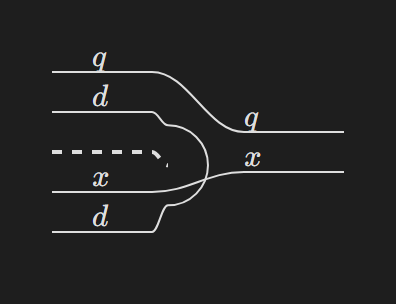

In [2]:
scores = ops.Einops.template('q d, x d -> q x')
notebook_listings.print_listing(scores, 'a contraction')
claim(ranks(scores) == ((2, 2), (2,)),
      'the contraction reads two rank-2 arrays and writes one')
await show(scores,
           "'q d, x d -> q x'. The letter d is in no output, so it is summed over.")

An operator without a template of its own is sized with `ops.sized(operator, input,
output)`. An integer means that many fresh axes, and a tuple of names or of axes names
them. `Linear.template`, `Normalize.template` and `SoftMax.template` are `sized` with
the operator filled in.

In [3]:
sized_softmax = ops.sized(ops.SoftMax(), 1)
claim(ranks(sized_softmax) == ((1,), (1,)),
      'a SoftMax sized by 1 reads and writes one axis')

holds: a SoftMax sized by 1 reads and writes one axis


## 2. `@` composes in sequence and aligns axes by position

`f @ g` connects the codomain of `f` to the domain of `g`. The two are lined up position
by position and each pair of axes is identified. Names play no part in that, so the
fresh axis of `SoftMax.template()` becomes the `x` of the scores because it stands at
the position where `x` is, and it would do so whatever it was called. Two letters
written in two templates are two axes until a composition puts them at the same
position.

--- attention ---
in    %0 : R[q, d], %1 : R[x, d], %2 : R[x, v]
out   %3 : R[q, v]
ops   2x Einops, 1x SoftMax
%4 = Einops(%0[q, {d}], %1[x, {d}]) : R[q, x]
%5 = SoftMax(%4[q, {x}]) : R[q, {x}]
%3 = Einops(%5[q, {x}], %2[{x}, v]) : R[q, v]

holds: attention reads Q, K and V and writes one array
The softmax consumes the axis that the scores wrote at its position.


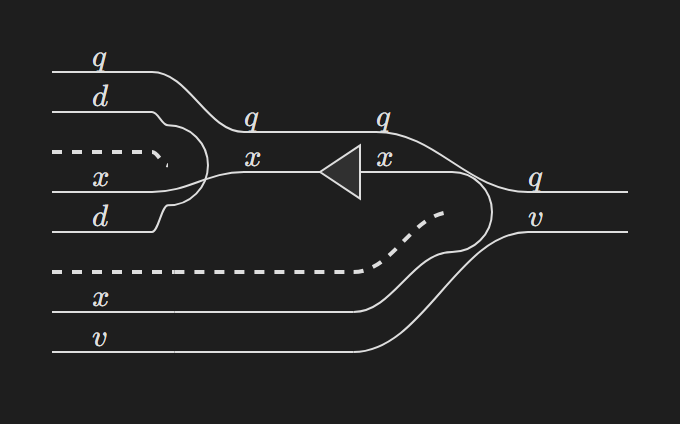

In [4]:
softmax = ops.SoftMax.template()
weighted = ops.Einops.template('q x, x v -> q v')
attention = scores @ softmax @ weighted
notebook_listings.print_listing(attention, 'attention')
claim(ranks(attention) == ((2, 2, 2), (2,)),
      'attention reads Q, K and V and writes one array')
await show(attention,
           'The softmax consumes the axis that the scores wrote at its position.')

A composition supplies what either side is missing. When the left side has more wires
than the right side reads, the surplus wires pass beside the right side as identities.
When the right side's array has more axes than the left side's, the left side is lifted
over the surplus axes. `Linear.template('m', 'f')` followed by a scalar map therefore
applies the map to every element.

A bare tuple on the left of `@` is a `Rearrangement`. Position `i` of its output is a
copy of input `mapping[i]`, so `(0, 0)` copies one wire into two and `(1, 0)` swaps two.
The domain of the tuple is read from the morphism it is composed with. A residual
connection is a copy, the body beside an identity, and an addition.

--- a residual feed-forward block ---
in    %0 : R[m]
out   %1 : R[m]
ops   1x AdditionOp, 2x Linear, 1x ReLU
%2 = Linear<in>(%0[{m}]) : R[{f}]
%3 = ReLU(%2[f]) : R[f]
%4 = Linear<out>(%3[{f}]) : R[{m}]
%1 = AdditionOp<+>(%4[m], %0[m]) : R[m]

holds: a residual block reads one wire and writes one wire
The copy, the body beside an identity, and the sum.


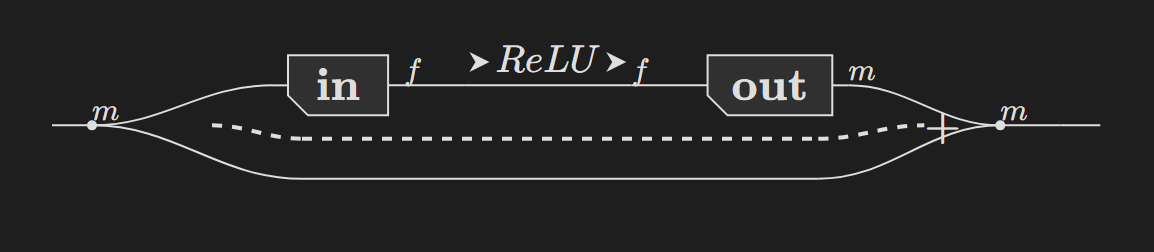

In [5]:
def residual(body):
    return (0, 0) @ body @ ops.AdditionOp.template()


feed_forward = (ops.Linear.template('m', 'f', name='in')
                @ ops.ReLU.template(name='ReLU')
                @ ops.Linear.template('f', 'm', name='out'))
residual_feed_forward = residual(feed_forward)
notebook_listings.print_listing(residual_feed_forward, 'a residual feed-forward block')
claim(ranks(residual_feed_forward) == ((1,), (1,)),
      'a residual block reads one wire and writes one wire')
await show(residual_feed_forward, 'The copy, the body beside an identity, and the sum.')

## 3. `*` composes in parallel, and an identity holds a wire

`f * g` puts two morphisms side by side. Its domain is the product of their domains. To
carry a wire past an operation unchanged, take the identity on its array,
`cat.ProdObject((array,)).identity()`. The `sota` notebooks call it `hold`. A tuple on
the left then routes one input into both branches.

holds: one input is copied, projected on one branch and held on the other
The held wire passes through an identity.


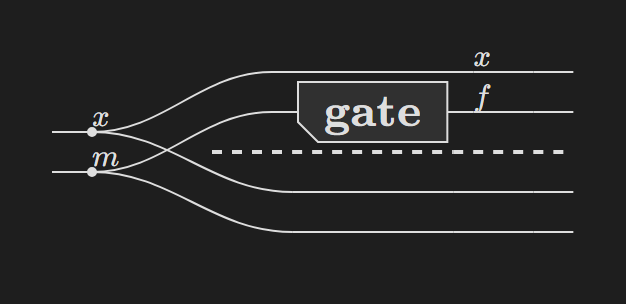

In [6]:
def hold(array):
    return cat.ProdObject((array,)).identity()


tokens, model = cat.RawAxis.named('x'), cat.RawAxis.named('m')
state = cat.Array(R, (tokens, model))
gate = tokens >> ops.Linear.template('m', 'f', name='gate')
gated_and_held = (0, 0) @ (gate * hold(state))
claim(ranks(gated_and_held) == ((2,), (2, 2)),
      'one input is copied, projected on one branch and held on the other')
await show(gated_and_held, 'The held wire passes through an identity.')

## 4. `>>` lifts a morphism over a batch axis

`axis >> morphism` broadcasts the morphism over that axis, on every input and every
output. It is how an operation written per token becomes one over a sequence. The batch
axis is the first axis of every array. A lift of one operation among several, as when a
softmax stands beside a held wire, is written with `lift.morphism_object_lift(morphism,
cat.ProdObject(axes))` on that operation alone, because `@` lifts a whole side of a
composition at once and would lift the held wire too.

A weight array is not lifted. A weight does not vary with the batch, and a lifted weight
would state that it is drawn once per batch element. State the batch axis in the einsum
beside the weight instead, as `'x m, m f -> x f'` does.

In [7]:
per_token = ops.Linear.template('m', 'd', name='Q')
over_tokens = cat.RawAxis.named('x') >> per_token
claim(ranks(per_token) == ((1,), (1,)) and ranks(over_tokens) == ((2,), (2,)),
      '>> adds one axis to the input and to the output')


def over(axes, morphism):
    return lift.morphism_object_lift(morphism, cat.ProdObject(tuple(axes)))


softmax_beside_state = over((tokens,), ops.SoftMax.template()) * hold(state)
claim(ranks(softmax_beside_state) == ((2, 2), (2, 2)),
      'the softmax is lifted over the tokens and the held wire is not touched')

holds: >> adds one axis to the input and to the output
holds: the softmax is lifted over the tokens and the held wire is not touched


## 5. A `Linear` holds its weight

`Linear.template(input, output, name)` is a contraction against a weight the operator
holds rather than names. `Linear : R[m] -> R[f]` holds `R[m, f]`. An integer size mints
that many fresh axes, so `Linear.template('m', 2, name='q')` writes a rank-2 array,
which the attention signature `'q h d, x h d -> h q x'` then names `h` and `d` by
position. `bias=True` adds the bias.

A structured target puts an axis on the weight. The up-projection of a mixture of
experts is `Linear (m,) -> (e, f)`, which holds every expert's weight and produces the
expert axis. Lifting a `Linear` over `e` would share one weight between the experts.

The down-projection is written the same way round. `Linear (f,) -> (e, m)`, broadcast
over the slots, produces the expert axis a second time, so on its own it gives one
output per slot and per expert. A diagonal then keeps the entries where the produced
expert and the slot's expert agree. The diagonal is a `View` whose reindexing is the
copy-`Rearrangement` `(e, m) -> (e, e, m)`. The gates land last, on the down-projected
outputs, as one dot product over the experts. Drawing the pieces out makes the combine a
visible reduction. In a model with a router, the selected slot axis meets the expert
axis at the diagonal, inside the block that holds it, so the router outside still scores
a dense `e`; [Sparse Axes](../../obsidian/02-categories/Sparse%20Axes.md) explains the
merge. Every notebook under `notebooks/sota/` draws the mixture this way.

The shorter statement of the same map is a down-projection that consumes
`(e, f) -> (m,)` whole, with the gates multiplied into the hidden state first, so that
its built-in sum over `e` is the routed combine. `Σₑ Wₑ(gₑ⊙hₑ) = Σₑ gₑ(Wₑhₑ)` is why the
gates may sit on either side. The folded form was the accepted one on 2026-08-15, and
the drawn form replaced it on 2026-08-18, because a reader sees the routed combine as a
reduction only when the pieces are drawn out.

> Rejected: a `GenericOperator` for an expert projection, or a weight array carried on a
> wire.
> Replacement: `Linear` in both directions.

> Rejected, as the form a model notebook draws: `Linear (e, f) -> (m,)` consuming the
> expert axis whole, with the gates multiplied in first.
> Replacement: `Linear (f,) -> (e, m)`, a `View` carrying the diagonal reindexing, and
> `Einops.template('e, e m -> m')` for the gates.

An index operand, whose datatype is `Natural(n)`, selects one of `n` weights rather than
contracting. That is the expanded form of a selection.

holds: an integer output size mints that many axes
holds: the expert axis rides the weight of the up-projection
holds: the down-projection produces the expert axis beside the slot axis
holds: the diagonal keeps each slot its own expert
holds: the gates land last, as one dot product over the experts
--- a mixture of experts as drawn: the down-projection produces e, the diagonal selects, the gates combine ---
in    %0 : R[e], %1 : R[e, f]
out   %2 : R[m]
ops   1x Einops, 1x Linear, 1x View
%3 = Linear<down>(%1[e, {f}]) : R[e, {e}, {m}]
%4 = View<diag>(%3[e, e, m]) : R[e, m]
%2 = Einops(%0[{e}], %4[{e}, m]) : R[m]

holds: the folded down-projection consumes the expert axis whole and sums over it
The down-projection produces the expert axis, the diagonal keeps each slot its own expert, and the gates combine the outputs.


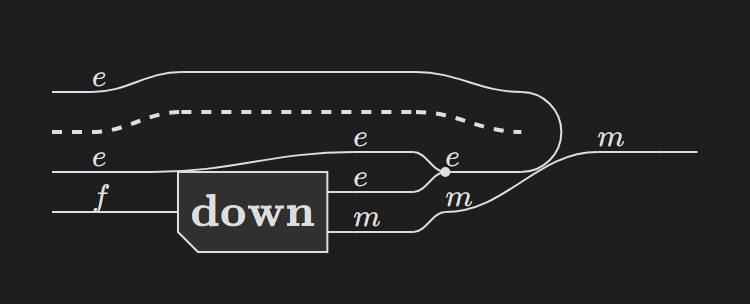

In [8]:
heads = ops.Linear.template('m', 2, name='q')
experts_up = ops.Linear.template(('m',), ('e', 'f'), name='up')
claim(ranks(heads) == ((1,), (2,)), 'an integer output size mints that many axes')
claim(ranks(experts_up) == ((1,), (2,)),
      'the expert axis rides the weight of the up-projection')

expert, hidden, model = (cat.RawAxis.named(letter) for letter in 'efm')
experts_down = over((expert,),
                    ops.Linear.template((hidden,), (expert, model), name='down'))
diagonal = ops.View.template(
    reindexing=cat.Rearrangement((0, 0, 1), (expert, model)), name='diag')
gates_last = ops.Einops.template('e, e m -> m')
mixture_drawn = (hold(cat.Array(R, (expert,))) * (experts_down @ diagonal)) @ gates_last
claim(ranks(experts_down) == ((2,), (3,)),
      'the down-projection produces the expert axis beside the slot axis')
claim(ranks(experts_down @ diagonal) == ((2,), (2,)),
      'the diagonal keeps each slot its own expert')
claim(ranks(mixture_drawn) == ((1, 2), (1,)),
      'the gates land last, as one dot product over the experts')
notebook_listings.print_listing(
    mixture_drawn, 'a mixture of experts as drawn: the down-projection produces e, '
    'the diagonal selects, the gates combine')

mixture_folded = (ops.Einops.template('e f, e -> e f')
                  @ ops.Linear.template(('e', 'f'), ('m',), name='down'))
claim(ranks(mixture_folded) == ((2, 1), (1,)),
      'the folded down-projection consumes the expert axis whole and sums over it')
await show(mixture_drawn,
           'The down-projection produces the expert axis, the diagonal keeps each '
           'slot its own expert, and the gates combine the outputs.')

### A linear map cut into parts is one linear map per part

A linear map followed by a slice of its results is the linear map whose weight is that slice of the rows, because result $i$ of a linear map reads row $i$ of the weight and nothing else. A model whose reference holds several maps as one weight and cuts the results apart therefore writes one `Linear` per part, each reading a copy of the input, and needs no axis to cut and no slice. The released DeepSeek-V4.1-Flash holds the three sets of mHC coefficients as one weight of 24 rows and cuts the 24 results into 4, 4 and 16, and the reviewer ruled on 2026-09-17 that the model writes three maps.

> Rejected: `ops.Linear.template((n, m), (y,), 'H', bias=True)` onto a 24-wide axis `y`, followed by three views that read `y` at the shifts 0, 4 and 8.
> Replacement: `ops.Linear.template((n, m), (n,), 'H_0', bias=True)`, `ops.Linear.template((n, m), (n,), 'H_1', bias=True)` and `ops.Linear.template((n, m), (n, N), 'H_2', bias=True)`, each reading a copy of the input.

holds: three maps of one input give the three parts with no axis to cut them from
holds: the parts need no slice
holds: a slice of the results of a linear map is the linear map of that slice of the rows
Three linear maps read one copy each of the input, where the reference cuts the results of one map into three parts.


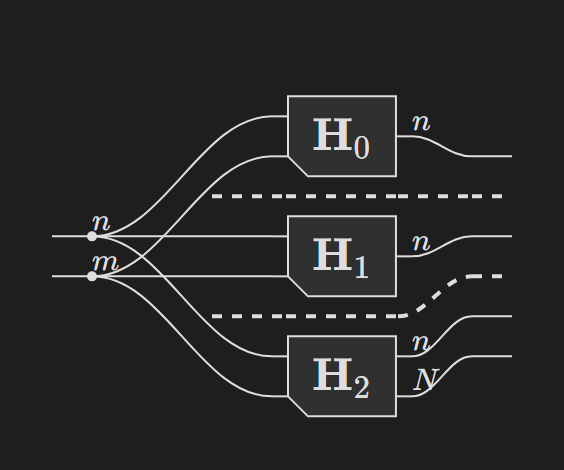

In [9]:
stream, hidden_width, second_stream = (cat.RawAxis.named(letter) for letter in 'nmN')
stream_array = cat.Array(R, (stream, hidden_width))
one_map_per_part = (
    cat.Rearrangement((0, 0, 0), (stream_array,))
    @ (ops.Linear.template((stream, hidden_width), (stream,), 'H_0', bias=True)
       * ops.Linear.template((stream, hidden_width), (stream,), 'H_1', bias=True)
       * ops.Linear.template((stream, hidden_width), (stream, second_stream), 'H_2',
                             bias=True)))
claim(ranks(one_map_per_part) == ((2,), (1, 1, 2)),
      'three maps of one input give the three parts with no axis to cut them from')
claim('3x Linear' in notebook_listings.operation_counts(one_map_per_part)
      and 'View' not in notebook_listings.operation_counts(one_map_per_part),
      'the parts need no slice')

whole_weight, whole_bias = torch.rand(24, 8), torch.rand(24)
map_inputs = torch.rand(5, 8)
claim(torch.allclose(
          torch.nn.functional.linear(map_inputs, whole_weight, whole_bias)[:, 4:8],
          torch.nn.functional.linear(map_inputs, whole_weight[4:8], whole_bias[4:8])),
      'a slice of the results of a linear map is the linear map of that slice of the rows')

await show(one_map_per_part,
           'Three linear maps read one copy each of the input, where the reference '
           'cuts the results of one map into three parts.')

## 6. An elementwise map with a formula is an `Arithmetic`

`Arithmetic.template(formula)` is an elementwise map given by a formula in `nm.x`. The
algebra differentiates the formula and `torch_compile` evaluates it, so a derived
backward pass is checkable against autograd. `Elementwise.template(name=...)` carries a
name and no formula: the derivative rule reverses it into the primed name, which states
nothing, and `torch_compile` evaluates every named `Elementwise` as a ReLU.
`ReLU.template(name='ReLU')` is the one named map that is what it says, and its
derivative is the formula `\mathbbm{1}_{x > 0}`.

> Rejected: `ops.Elementwise.template(name='SiLU')`.
> Replacement: `ops.Arithmetic.template(nm.x * nm.Sigmoid(nm.x))`.

A function that the primitive numerics can also spell is written with its own numeric.
`nm.Sigmoid` and `nm.RectifiedLinear` are `nm.Expandable`. Each stays whole in a formula
and in its derivative, and `expand_to_primitives` writes it in the primitive numerics
only when a pass has to compare two formulas spelled differently.
`nm.RectifiedLinear(nm.x)` expands to `x \mathbbm{1}_{x > 0}`, where `nm.IsPositive` is
the indicator `\mathbbm{1}_{x > 0}`, so its derivative is `\mathbbm{1}_{x > 0}`. A
clamp on one side is written with it.

> Rejected: `(v + L - sqrt((v - L)^2)) / 2` for a clamp at `L`, whose reader has to
> work out that it is a clamp.
> Replacement: `ops.Arithmetic.template(nm.x - nm.RectifiedLinear(nm.x - L))`.

A clamp between two bounds is an `nm.Clamp`, which is an `nm.Expandable` too.
`nm.Clamp(y)` holds `y` between 0 and 1 and prints between corner brackets,
`\ulcorner y \lrcorner`. `nm.Clamp(y, lower, upper)` holds `y` between the two bounds and
writes them on the closing bracket. It expands to
`lower + (y - lower) \mathbbm{1}_{y - lower > 0} - (y - upper) \mathbbm{1}_{y - upper > 0}`,
so its derivative is the difference of the two indicators.

> Rejected: `nm.RectifiedLinear(y) - nm.RectifiedLinear(y - 1)` for a ramp held between
> 0 and 1, whose reader has to work out that it is a clamp.
> Replacement: `nm.Clamp(y)`.

The sign, the magnitude, the larger of two values and the square root are `nm.Sign`,
`nm.AbsoluteValue`, `nm.LargerOf` and `nm.SquareRoot`, and each is an `nm.Expandable`
as well. A formula keeps the symbol of the function, and the spelling in the primitive
numerics exists in `expand_to_primitives` alone. An inspection box over the map shows
the formula as written and spells no such function out, because every one of them is
a function a reader knows. `nm.LargerOf` is named for what it returns because
`ops.Maximum` is the reduction operator and a `Term` class name is registered once.

> Rejected: `sign = 2 * nm.IsPositive(d) - 1`, `magnitude = d * sign` and
> `nm.Power.template(EPSILON + nm.RectifiedLinear(magnitude - EPSILON), 1 / 2)` for
> the signed root of a magnitude held above epsilon.
> Replacement: `nm.Sign(d) * nm.SquareRoot(nm.LargerOf(nm.AbsoluteValue(d), EPSILON))`.

In [10]:
silu = ops.Arithmetic.template(nm.x * nm.Sigmoid(nm.x))
relu = ops.ReLU.template(name='ReLU')
claim(isinstance(silu.operator, ops.Arithmetic), 'the formula is held by the operator')
claim(ranks(silu) == ((0,), (0,)),
      'an elementwise map has a rank-0 target, and lifts over whatever it is composed '
      'after')
notebook_listings.print_listing(cat.RawAxis.named('f') >> silu, 'silu over f')

holds: the formula is held by the operator
holds: an elementwise map has a rank-0 target, and lifts over whatever it is composed after
--- silu over f ---
in    %0 : R[f]
out   %1 : R[f]
ops   1x Arithmetic
%1 = Arithmetic<x \sigma(x)>(%0[f]) : R[f]



In [ ]:
clamp_above_ten = ops.Arithmetic.template(nm.x - nm.RectifiedLinear(nm.x - 10))
claim(nm.Sigmoid(nm.x).expand_to_primitives() == 1 / (1 + nm.E ** -nm.x),
      'the logistic function expands to (1 + e^{-x})^{-1}')
claim(nm.RectifiedLinear(nm.x).expand_to_primitives() == nm.x * nm.IsPositive(nm.x),
      'the rectified linear function expands to x 1_{x > 0}')
claim(ops.Arithmetic(formula=nm.RectifiedLinear(nm.x)).derivative().formula
      == nm.IsPositive(nm.x),
      'the derivative of the rectified linear function is 1_{x > 0}')
claim(clamp_above_ten.operator.derivative().formula == 1 - nm.IsPositive(nm.x - 10),
      'the derivative of the clamp is one below the bound and zero above it')
notebook_listings.print_listing(cat.RawAxis.named('f') >> clamp_above_ten,
                                'a clamp above 10 over f')
clamp_to_unit_interval = ops.Arithmetic.template(nm.Clamp(nm.x))
claim(nm.Clamp(nm.x).expand_to_primitives()
      == nm.x * nm.IsPositive(nm.x) - (nm.x - 1) * nm.IsPositive(nm.x - 1),
      'the clamp to the unit interval expands to x 1_{x > 0} - (x - 1) 1_{x - 1 > 0}')
claim(clamp_to_unit_interval.operator.derivative().formula
      == nm.IsPositive(nm.x) - nm.IsPositive(nm.x - 1),
      'the derivative of the clamp is one between the bounds and zero outside them')
claim(clamp_to_unit_interval.operator.name.to_latex() == '\\ulcorner x \\lrcorner'
      and nm.Clamp(nm.x, nm.Integer(-10), nm.Integer(10)).to_latex()
      == '\\ulcorner x \\lrcorner_{-10}^{10}',
      'the clamp to the unit interval prints between corner brackets alone, and any '
      'other bounds are written on the closing bracket')
signed_root = ops.Arithmetic.template(
    nm.Sign(nm.x) * nm.SquareRoot(nm.LargerOf(nm.AbsoluteValue(nm.x), nm.Integer(1) / 4)))
claim(nm.Sign(nm.x).expand_to_primitives() == nm.IsPositive(nm.x) - nm.IsPositive(-nm.x),
      'the sign expands to 1_{x > 0} - 1_{-x > 0}')
claim(nm.AbsoluteValue(nm.x).expand_to_primitives() == nm.x * nm.Sign(nm.x),
      'the magnitude expands to x times its sign')
claim(nm.LargerOf(nm.x, nm.Integer(2)).expand_to_primitives()
      == nm.x + (2 - nm.x) * nm.IsPositive(2 - nm.x),
      'the larger of x and 2 expands to x + (2 - x) 1_{2 - x > 0}')
claim(nm.SquareRoot(nm.x).expand_to_primitives() == nm.x ** (nm.Integer(1) / 2),
      'the square root expands to the power x^{1/2}')
claim(signed_root.operator.name.to_latex()
      == '\\operatorname{sign}(x) \\sqrt{\\max(\\lvert x \\rvert, 4^{-1})}',
      'the formula keeps the symbol of every function')
claim(ops.Arithmetic(formula=nm.AbsoluteValue(nm.x)).derivative().formula == nm.Sign(nm.x),
      'the derivative of the magnitude is the sign')
notebook_listings.print_listing(cat.RawAxis.named('f') >> signed_root,
                                'a signed root with a floor over f')


## 7. Products, sums and norms are standard operators

Reach for a standard operator first, and add a custom one only for new semantics. An
elementwise product is an einsum along one letter, `'f, f -> f'`, broadcast over
everything else. The unit-axis spelling `'1, 1 -> 1'` parses, and alignment cannot merge
a literally sized axis, so it is not written. Addition is `AdditionOp.template()`, RMS
normalisation is `Normalize.template()`, and `SoftMax.template()` consumes the last axis
of the array it is composed after.

> Rejected: `ops.GenericOperator.template('⊙', 'f, f -> f')`.
> Replacement: `ops.Einops.template('f, f -> f')`.

--- a gated MLP block ---
in    %0 : R[x, m]
out   %1 : R[x, m]
ops   1x AdditionOp, 1x Arithmetic, 1x Einops, 3x Linear, 1x Normalize
%2 = Linear<gate>(%0[x, {m}]) : R[x, {f}]
%3 = Arithmetic<x \sigma(x)>(%2[x, f]) : R[x, f]
%4 = Linear<up>(%0[x, {m}]) : R[x, {f}]
%5 = Einops(%3[x, f], %4[x, f]) : R[x, f]
%6 = Linear<down>(%5[x, {f}]) : R[x, {m}]
%7 = AdditionOp<+>(%6[x, m], %0[x, m]) : R[x, m]
%1 = Normalize<RMSNorm>(%7[x, {m}]) : R[x, {m}]

holds: the block reads and writes one array over tokens
Gate, up, product, down, residual sum and norm, over tokens.


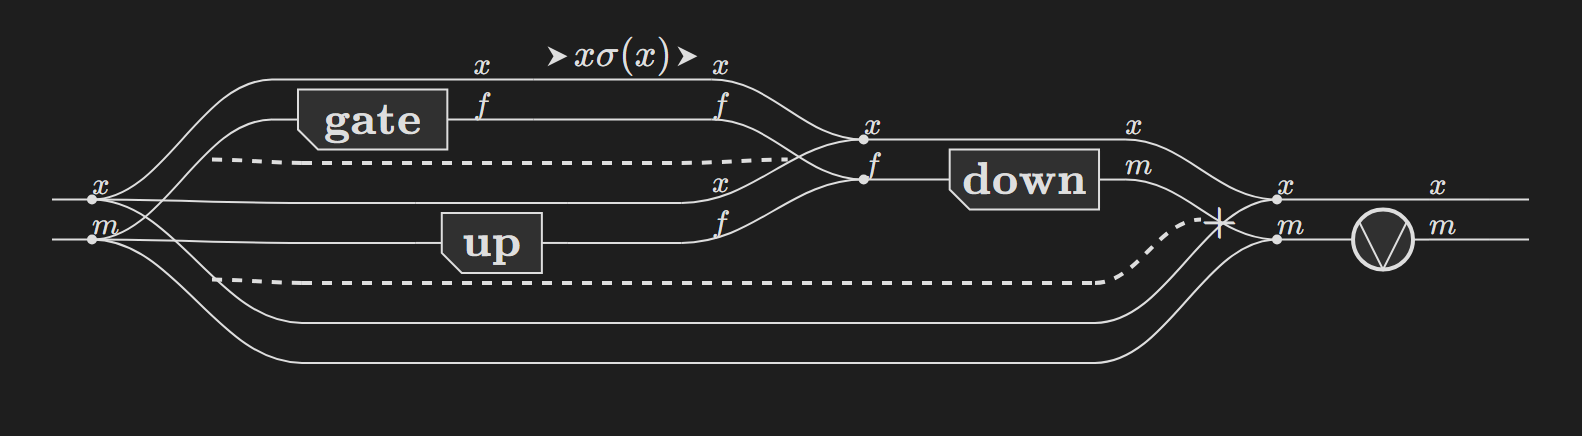

In [12]:
def gated_mlp():
    gate = ops.Linear.template('m', 'f', name='gate') @ ops.Arithmetic.template(
        nm.x * nm.Sigmoid(nm.x))
    up = ops.Linear.template('m', 'f', name='up')
    product = ops.Einops.template('f, f -> f')
    down = ops.Linear.template('f', 'm', name='down')
    return (0, 0) @ (gate * up) @ product @ down


mlp_block = cat.RawAxis.named('x') >> (residual(gated_mlp()) @ ops.Normalize.template())
notebook_listings.print_listing(mlp_block, 'a gated MLP block')
claim(ranks(mlp_block) == ((2,), (2,)),
      'the block reads and writes one array over tokens')
await show(mlp_block,
           'Gate, up, product, down, residual sum and norm, over tokens.')

### Dividing by a sum is an `L1Norm`

`L1Norm.template()` is `y = x / (sum(x) + epsilon)` over the axis it consumes, which at
`ops.NO_EPSILON` is the normalisation a `SoftMax` performs after its exponential.
Written out it is a copy, a contraction, a reciprocal and a product, and a model that
writes those four states in four operations what the operator states in one. The
divisor is the sum of the values and not their mean.

`epsilon` is the number a released kernel adds to the divisor so that an axis whose
values have all underflowed to zero is not divided by zero. The Sinkhorn normalisation
and the gate of the mixture of experts of DeepSeek-V4.1-Flash each supply the number
their kernel adds, and `ops.NO_EPSILON` is the unit of addition, so a norm that adds
none writes the bare reciprocal.

`operator_expansion` holds both identities. `rewrite_softmax_as_l1_norm` turns a
`SoftMax` into the exponential and the norm, and `expand_l1_norm` writes the norm out, so
`expand_softmax` is the two in turn and returns what it always returned.

> Rejected: `(0, 0) @ (identity * (ops.Einops.template('k -> ') @ reciprocal))
> @ ops.Einops.template('k, -> k')`.
> Replacement: `ops.L1Norm.template()`.
> Rejected: a copy, a contraction and an `ops.Arithmetic` named
> `(x + \varepsilon)^{-1}`, for a division by a sum plus an epsilon.
> Replacement: `ops.L1Norm.template(epsilon=...)`.

In [ ]:
l1_norm = cat.RawAxis.named('q') >> ops.L1Norm.template()
notebook_listings.print_listing(l1_norm, 'an L1 norm over the axis it consumes')
claim(ranks(l1_norm) == ((2,), (2,)),
      'the norm reads and writes one array of the same rank')

values = torch.rand(3, 4)
claim(torch.allclose(torch_compile.ConstructedModule.construct(l1_norm)(values),
                     values / values.sum(dim=-1, keepdim=True)),
      'the compiled norm divides along the consumed axis by the sum along it')

softmax = cat.RawAxis.named('q') >> ops.SoftMax.template()
one_step = operator_expansion.rewrite_softmax_as_l1_norm(softmax)
notebook_listings.print_listing(one_step, 'the same softmax as an exponential and a norm')
claim('1x Arithmetic, 1x L1Norm' in notebook_listings.operation_counts(one_step),
      'a softmax is an exponential followed by an L1 norm')
claim(notebook_listings.listing_without_legend(
          operator_expansion.expand_softmax(softmax))
      == notebook_listings.listing_without_legend(
          operator_expansion.expand_l1_norms(one_step)),
      'expanding the softmax and expanding its norm give one expression')

await show(l1_norm, 'The L1 norm over the axis it consumes, lifted over a batch axis.')


def reciprocal_names(norm):
    return [node.operator.name.to_latex()
            for node in tutil.type_search(
                cat.Broadcasted, operator_expansion.expand_l1_norm(norm))
            if isinstance(node.operator, ops.Arithmetic)]


epsilon = nm.FreeNumeric.named('\\varepsilon')
guarded = cat.RawAxis.named('q') >> ops.L1Norm.template(epsilon=epsilon)
claim(reciprocal_names(guarded) == ['(x + \\varepsilon)^{-1}'],
      'the epsilon of an L1 norm reaches the reciprocal of its expansion')
claim(reciprocal_names(l1_norm) == ['x^{-1}'],
      'a norm that adds no epsilon writes the bare reciprocal')

### An `RMSNorm` declares its gain, its bias and its epsilon

`Normalize.template(shape, gain=..., bias=..., epsilon=...)` is
`y = gamma * x * (mean(x^2) + epsilon)^{-1/2} + beta` over every axis in `shape`. `gain`
says that the result is multiplied by `gamma`, which is one learned number per position
of those axes, and `bias` says that `beta` is added after it, which is one learned
number per position as well. `para.processing.show_grabbed_parameters.parameter_arrays`
grabs whichever of the two the operator declares, the gain first, and
`algebra.operator_expansion.expand_normalize` writes the scaling alone where it declares
neither.

`epsilon` is the number added under the root. `ops.SYMBOLIC_EPSILON` stands for it where
a model does not say what the number is, and `ops.NO_EPSILON` is zero, which the
addition folds away. The four streams of a token in the Single-Pass mHC of
DeepSeek-V4.1-Flash are normalised with no learned weight, so the exact model writes an
`RMSNorm` declaring neither the gain nor the bias, and the integrated model writes the
same operator carrying the epsilon the released kernel adds.

`L2Norm.template(shape)` divides by the root of the sum of the squares rather than of
their mean, so its result has length one, and it takes neither a learned weight nor an
epsilon. A normalisation stated as a division by the root of a sum writes that operator.

> Rejected: `ops.L2Norm.template((n, m))` followed by the root of the number of values,
> for an array whose normalisation has no learned weight.
> Replacement: `ops.Normalize.template((n, m), gain=False, bias=False, epsilon=...)`.

In [ ]:
n_axis, m_axis = cat.RawAxis.named('n'), cat.RawAxis.named('m')
rms_norm = ops.Normalize.template((n_axis, m_axis), gain=False, bias=False,
                                  epsilon=ops.NO_EPSILON)
notebook_listings.print_listing(rms_norm, 'an RMSNorm over the two axes it consumes')
claim(ranks(rms_norm) == ((2,), (2,)),
      'the norm reads and writes one array of the same rank')

streams = torch.rand(4, 6)
claim(torch.allclose(torch_compile.ConstructedModule.construct(rms_norm)(streams),
                     streams / streams.pow(2).mean().sqrt(), atol=1e-6),
      'the compiled norm divides by the root of the mean of the squares')

claim(show_grabbed_parameters.parameter_arrays(rms_norm) == (),
      'a norm declaring neither a gain nor a bias grabs nothing')
weighted_norm = ops.Normalize.template((n_axis, m_axis), gain=True, bias=True)
claim(tuple(name.to_latex() for name, _
            in show_grabbed_parameters.parameter_arrays(weighted_norm))
      == ('\\gamma', '\\beta'),
      'a norm declaring both grabs the gain and then the bias')
claim(tuple(len(tuple(array.shape()))
            for _, array in show_grabbed_parameters.parameter_arrays(weighted_norm))
      == (2, 2),
      'the gain and the bias each carry the normalised axes')

l2_norm = ops.L2Norm.template((n_axis, m_axis))
claim(torch.allclose(torch_compile.ConstructedModule.construct(l2_norm)(streams),
                     streams / streams.pow(2).sum().sqrt()),
      'an L2 norm divides by the root of the sum of the squares instead')

await show(rms_norm,
           'The RMS normalisation of an array carrying no learned gain, over both of '
           'its axes at once.')

### A softmax before repeated normalisations is an exponential

A `SoftMax` is an exponential followed by an `L1Norm`, as the section above states. Where a softmax stands before a repetition of normalisations of the same axis, its normalisation is one more turn of the repetition, so the model writes the exponential and lets the repetition hold every normalisation. The Sinkhorn normalisation of the released DeepSeek-V4.1-Flash takes a row softmax, a column normalisation and nineteen rounds of a row and a column normalisation, and the reviewer ruled on 2026-09-17 that the model writes the exponential and twenty rounds, which is the round count of the released configuration. The two are equal where the model leaves out the epsilons of the reference, which adds one after the softmax and one to every later sum.

> Rejected: `over((n,), ops.SoftMax.template()) @ columns @ cat.Block.template(rows @ columns, repetition=19)`.
> Replacement: `over((n, N), exponential) @ cat.Block.template(rows @ columns, repetition=20)`.

holds: the exponential stands where the softmax stood
holds: a softmax, a column norm and two rounds equal an exponential and three rounds
The exponential of every entry, then a repetition of a row normalisation and a column normalisation.


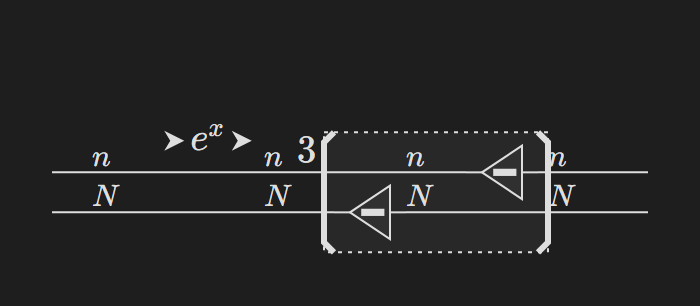

In [14]:
def l1_norm_at(shape, normalised_position):
    weave = cat.Weave(R, tuple(
        axis if position == normalised_position else cat.WeaveMode.TILED
        for position, axis in enumerate(shape)))
    degree = tuple(axis for position, axis in enumerate(shape)
                   if position != normalised_position)
    return cat.Broadcasted(
        operator=ops.L1Norm(), input_weaves=(weave,), output_weaves=(weave,),
        reindexings=(cat.ProdObject(degree).identity(),))

matrix_axes = tuple(cat.RawAxis.named(letter) for letter in 'nN')
rows, columns = l1_norm_at(matrix_axes, 1), l1_norm_at(matrix_axes, 0)
softmax_then_rounds = (over(matrix_axes[:1], ops.SoftMax.template()) @ columns
                       @ cat.Block.template(rows @ columns, repetition=2))
exponential_then_rounds = (over(matrix_axes, ops.Arithmetic.template(nm.E ** nm.x))
                           @ cat.Block.template(rows @ columns, repetition=3))
claim('SoftMax' not in notebook_listings.operation_counts(exponential_then_rounds),
      'the exponential stands where the softmax stood')

def compiled_at_four(morphism):
    sizes = generate_config.NumericConfig.template(morphism)
    sizes.assign_values(n=4, N=4)
    return torch_compile.ConstructedModule.construct(sizes(morphism))

matrix_entries = torch.randn(4, 4)
softmax_result, = compiled_at_four(softmax_then_rounds)(matrix_entries)
exponential_result, = compiled_at_four(exponential_then_rounds)(matrix_entries)
claim(torch.allclose(softmax_result, exponential_result),
      'a softmax, a column norm and two rounds equal an exponential and three rounds')

await show(exponential_then_rounds,
           'The exponential of every entry, then a repetition of a row normalisation '
           'and a column normalisation.')

## 8. An axis is identified by its uid, and one axis may stand at two positions

`cat.RawAxis.named('x')` called twice gives two axes with different uids and one printed
name. Alignment identifies axes by position and never by name, so two templates that
both say `x` are joined only where a composition puts them at the same position.

When one declared axis must appear at several places, as the token axis does in
self-attention from one input, `@` supplies the identity: copying the input into the
three projections puts the same token axis at both positions of the scores. Read by
position, that morphism is not a diagonal. It is a contraction whose result has one axis
at two positions, and every rule in the package reads a `Broadcasted` that way.

A contraction built by hand from declared axes uses
`einops_simplification.einsum(inputs, output)` over the axis objects. `Einops.template`
mints fresh axes, and a minted axis composed onto a declared one can win canonicality
and rename the declared one throughout the term. Where one axis is read by two index
variables, write the shapes in `IndexVariable`s.

> Rejected: `ops.Einops.template('x d, x d -> x x')` beside declared axes.
> Replacement: `einops_simplification.einsum(((query, channel), (key, channel)), (query,
> key))` with `query` and `key` two `IndexVariable`s over the one token axis.

In [15]:
first, second = cat.RawAxis.named('x'), cat.RawAxis.named('x')
claim(first != second and first.uid != second.uid,
      'two named axes with one name are two axes')

self_attention = (
    (0, 1, 0, 2, 0, 3)
    @ (ops.Einops.template('x m, m d -> x d')
       * ops.Einops.template('x m, m d -> x d')
       * ops.Einops.template('x m, m v -> x v'))
    @ (ops.Einops.template('q d, x d -> q x') @ ops.SoftMax.template()
       @ ops.Einops.template('q x, x v -> q v')))
notebook_listings.print_listing(self_attention, 'self-attention from one input')
claim(ranks(self_attention) == ((2, 2, 2, 2), (2,)),
      'the tokens and three weights come in and one array comes out')

token, channel_axis = cat.RawAxis.named('x'), cat.RawAxis.named('d')
query = einops_simplification.IndexVariable('query', token)
key = einops_simplification.IndexVariable('key', token)
channel = einops_simplification.IndexVariable('channel', channel_axis)
declared_scores = einops_simplification.einsum(
    ((query, channel), (key, channel)), (query, key), R)
result = tuple(declared_scores.cod())[0].shape()
claim(result[0] is result[1], 'the result carries the one token axis at both positions')

holds: two named axes with one name are two axes
--- self-attention from one input ---
in    %0 : R[x, m], %1 : R[m, d], %2 : R[m, d], %3 : R[m, v]
out   %4 : R[x, v]
ops   5x Einops, 1x SoftMax
%5 = Einops(%0[x, {m}], %1[{m}, d]) : R[x, d]
%6 = Einops(%0[x, {m}], %2[{m}, d]) : R[x, d]
%7 = Einops(%5[x, {d}], %6[x, {d}]) : R[x, x]
%8 = SoftMax(%7[x, {x}]) : R[x, {x}]
%9 = Einops(%0[x, {m}], %3[{m}, v]) : R[x, v]
%4 = Einops(%8[x, {x}], %9[{x}, v]) : R[x, v]

holds: the tokens and three weights come in and one array comes out
holds: the result carries the one token axis at both positions


Every axis of the result of a contraction is a degree position. An `Einops` writes no
axis of its own, so its output weave holds tiled positions alone. An axis the result shares
with an operand is a degree axis, and the operand's reindexing names it. The target
positions of an operand are the axes it contracts, and the signature gives each of them a
contraction group. `einsum` over the declared axes builds that layout from the shapes.

A `Broadcasted` built by hand can write an axis as a target of an operand and again as a
target of the result. The two positions are then related by the uid of the axis alone.
Read by position, the operand has a contracted position with no contraction group, and the
result has a position that no operand supplies. `agent_display` prints the axis in braces
on both sides, and braces mark an axis the operation consumes. The renderer draws the two
wires unconnected. The hand-built form has the domain and the codomain of the correct one,
so an assertion on the ends of a chain does not catch it.

> Rejected: DeepSeek-V4.1-Flash's grouped output projection as a hand-built `Broadcasted`
> whose weight weave is `(T, j, c, o)` and whose result weave is `(T, T, o)`, with both
> reindexings read from the degree `(x, g)`, where `T` is `cat.WeaveMode.TILED`.
> Replacement: `einops_simplification.einsum(((x, g, j, c), (g, j, c, o)), (x, g, o))`,
> whose degree is `(x, g, o)`, whose weight weave is `(T, j, c, T)` read at `(g, o)`, and
> whose result weave is `(T, T, T)`.

In [16]:
sequence, group, head_in_group, head_width, rank = (
    cat.RawAxis.named(letter) for letter in 'xgjco')
grouped = einops_simplification.einsum(
    ((sequence, group, head_in_group, head_width), (group, head_in_group, head_width, rank)),
    (sequence, group, rank), R)
claim(not tuple(grouped.output_weaves[0].target().shape()),
      'every axis of the result of a contraction is a degree position')
operand_indices, result_indices, _ = einops_simplification.index_shapes(grouped)
claim(operand_indices[1][0] == result_indices[1]
      and operand_indices[1][-1] == result_indices[-1],
      'the weight is read at the group and rank positions of the result')

tiled = cat.WeaveMode.TILED
rank_in_target = cat.Broadcasted(
    operator=ops.Einops(signature=((0, 1), (0, 1))),
    input_weaves=(cat.Weave(R, (tiled, tiled, head_in_group, head_width)),
                  cat.Weave(R, (tiled, head_in_group, head_width, rank))),
    output_weaves=(cat.Weave(R, (tiled, tiled, rank)),),
    reindexings=(cat.Rearrangement((0, 1), (sequence, group)),
                 cat.Rearrangement((1,), (sequence, group))))
claim(tuple(rank_in_target.dom()) == tuple(grouped.dom())
      and tuple(rank_in_target.cod()) == tuple(grouped.cod()),
      'the rejected form has the domain and the codomain of the replacement')
claim(len(rank_in_target.operator.signature[1])
      < len(tuple(rank_in_target.input_weaves[1].target().shape())),
      "the rejected form's signature gives the weight's rank position no contraction "
      'group')
notebook_listings.print_listing(grouped, 'the rank axis in the degree')
notebook_listings.print_listing(rank_in_target, 'the rank axis in two targets')

holds: every axis of the result of a contraction is a degree position
holds: the weight is read at the group and rank positions of the result
holds: the rejected form has the domain and the codomain of the replacement
holds: the rejected form's signature gives the weight's rank position no contraction group
--- the rank axis in the degree ---
in    %0 : R[x, g, j, c], %1 : R[g, j, c, o]
out   %2 : R[x, g, o]
ops   1x Einops
%2 = Einops(%0[x, g, {j}, {c}], %1[g, {j}, {c}, o]) : R[x, g, o]

--- the rank axis in two targets ---
in    %0 : R[x, g, j, c], %1 : R[g, j, c, o]
out   %2 : R[x, g, o]
ops   1x Einops
%2 = Einops(%0[x, g, {j}, {c}], %1[g, {j}, {c}, {o}]) : R[x, g, {o}]



### A contraction against a parameter array is a `Linear` that produces its axes

A weight may stand on a wire, as a parameter array with no inputs, and be contracted
against the data by an `Einops`. The same map is an `ops.Linear` that produces the axes
the array held, broadcast over the axes the two share, followed by the diagonalisation
that keeps the entries where the axis the weight produced and the axis of the input
agree. The `Linear` form holds the weight inside the operator, which is the form every
other weight in a model takes, and it leaves the reader nothing to check about which
positions of the weight are contracted and which are shared. The diagonalisation is the
copy-`Rearrangement` reindexing the down-projection of a mixture of experts already
uses.

> Rejected: `einops_simplification.einsum(((x, g, j, c), (g, j, c, o)), (x, g, o))`
> against a `weights()` array on `(g, j, c, o)`, the form DeepSeek-V4.1-Flash's grouped
> output projection had until 2026-09-15.
> Replacement: `ops.Linear.template((j, c), (g, o))` lifted over `(x, g)`, followed by
> `ops.View.template(reindexing=cat.Rearrangement((0, 1, 1, 2), (x, g, o)))`.

In [17]:
weight_inside = lift.morphism_object_lift(
    ops.Linear.template((head_in_group, head_width), (group, rank), name='W'),
    cat.ProdObject((sequence, group)))
diagonal = ops.View.template(
    reindexing=cat.Rearrangement((0, 1, 1, 2), (sequence, group, rank)), name='diag')
produced = weight_inside @ diagonal
claim(tuple(weight_inside.cod()[0].shape()) == (sequence, group, group, rank),
      'the Linear produces the group beside the group it is read at')
claim(diagonal.reindexings[0].mapping == (0, 1, 1, 2),
      'the diagonal keeps the entries where the two groups agree')
claim(tuple(produced.dom()) == (grouped.dom()[0],),
      'the weight left the domain, because the Linear holds it')
claim(tuple(produced.cod()) == tuple(grouped.cod()),
      'the two forms write the same array')
notebook_listings.print_listing(
    produced, 'the weight inside the operator, with the diagonal after it')

holds: the Linear produces the group beside the group it is read at
holds: the diagonal keeps the entries where the two groups agree
holds: the weight left the domain, because the Linear holds it
holds: the two forms write the same array
--- the weight inside the operator, with the diagonal after it ---
in    %0 : R[x, g, j, c]
out   %1 : R[x, g, o]
ops   1x Linear, 1x View
%2 = Linear<W>(%0[x, g, {j}, {c}]) : R[x, g, {g}, {o}]
%1 = View<diag>(%2[x, g, g, o]) : R[x, g, o]



## 9. A block groups, and a repetition denotes a loop

`cat.Block.template(body, title=, fill_color=, repetition=)` groups a morphism for
drawing and for the passes that read blocks. A `repetition` other than one denotes a
loop over the body. A kernel block is marked by its `aesthetics`, which fusion sets and
a notebook does not. `ops.BlockOperator.template(block, name)` draws a block as one
named box with its body rendered once beside the figure, which is how the whole-model
figures under `notebooks/sota/` stay legible.

The projections write `R[h, d]` and the attention signature reads `R[q, h, d]`, so the
composition lifts the projections over `q`, and aligning the key operand then identifies
`q` with `x`. The layer therefore reads `R[x, m]`. Queries and keys are the same tokens,
and the composition states that identity by position.

holds: the block carries its repetition
--- a transformer layer ---
in    %0 : R[x, m]
out   %1 : R[x, m]
ops   2x AdditionOp, 2x Einops, 6x Linear, 1x ReLU, 1x SoftMax
loop 6 times {
  %2 = Linear<q>(%0[x, {m}]) : R[x, {h}, {d}]
  %3 = Linear<k>(%0[x, {m}]) : R[x, {h}, {d}]
  %4 = Einops(%2[x, h, {d}], %3[x, h, {d}]) : R[h, x, x]
  %5 = SoftMax(%4[h, x, {x}]) : R[h, x, {x}]
  %6 = Linear<v>(%0[x, {m}]) : R[x, {h}, {d}]
  %7 = Einops(%5[h, x, {x}], %6[{x}, h, d]) : R[x, h, d]
  %8 = Linear<o>(%7[x, {h}, {d}]) : R[x, {m}]
  %9 = AdditionOp<+>(%8[x, m], %0[x, m]) : R[x, m]
  %10 = Linear<in>(%9[x, {m}]) : R[x, {f}]
  %11 = ReLU(%10[x, f]) : R[x, f]
  %12 = Linear<out>(%11[x, {f}]) : R[x, {m}]
  %1 = AdditionOp<+>(%12[x, m], %9[x, m]) : R[x, m]
}

holds: the layer reads and writes R[x, m], because composing the projections onto the attention signature lifted them over the sequence axis
Six repetitions of attention and feed-forward, each with a residual.


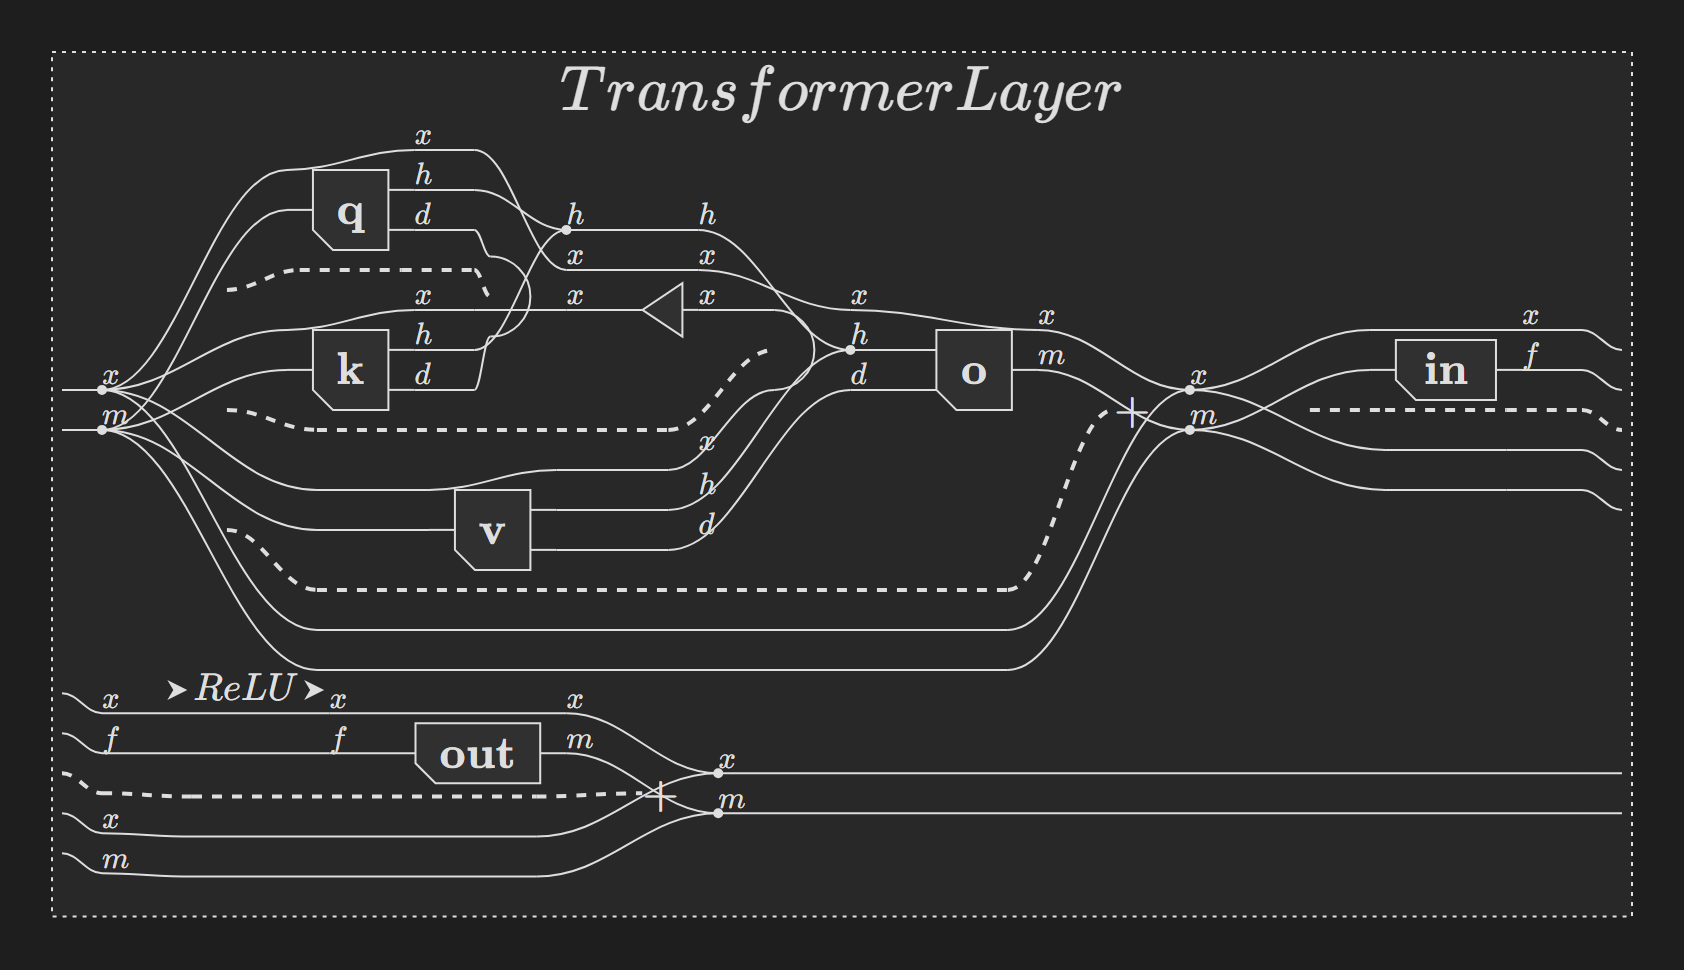

In [18]:
attention_projections = (ops.Linear.template('m', 2, name='q')
                         * ops.Linear.template('m', 2, name='k')
                         * ops.Linear.template('m', 2, name='v'))
attention_core = (ops.Einops.template('q h d, x h d -> h q x')
                  @ ops.SoftMax.template()
                  @ ops.Einops.template('h q x, x h d -> q h d'))
attention_layer = ((0, 0, 0) @ attention_projections @ attention_core
                   @ ops.Linear.template(2, 'm', name='o'))
transformer_layer = cat.Block.template(
    residual(attention_layer) @ residual(feed_forward),
    title='Transformer Layer', fill_color='#F3F3F4', repetition=6)
claim(transformer_layer.block_tag.repetition == nm.Integer(6),
      'the block carries its repetition')
notebook_listings.print_listing(transformer_layer, 'a transformer layer')
claim(ranks(transformer_layer) == ((2,), (2,)),
      'the layer reads and writes R[x, m], because composing the projections onto the '
      'attention signature lifted them over the sequence axis')
await show(transformer_layer,
           'Six repetitions of attention and feed-forward, each with a residual.')

### Broadcasting a block over an axis

A body computed once per index of an axis is one `ops.BlockOperator` broadcast over that
axis. Each operand's weave tiles as many positions as that operand's reindexing names, in
front of the target the body receives, so an operand that varies with the axis has a tiled
slot and one shared by every index has none. Every result tiles the whole degree, because
an operation is computed once per index of it and every result of that computation is
indexed by it. The axis has to lead in every array of the body and in every `Einops`
result, and `confirm_broadcast_expansion` expands the candidate and compares it against
the written-out form, so a candidate that states the wrong operand varies is refused with
the position it disagrees on. `obsidian/02-categories/Discovering Broadcasts.md` holds the
mathematics.

> Rejected: the attention core of DeepSeek-V4.1-Flash written out, with the head axis in
> the degree of all eleven of its operations and in seven of its arrays, and the
> reindexings `((0,), (0,), (), ())` of the broadcast form stated in prose alone.
> Replacement: `discovering_broadcasts.discover_broadcast_over_axes(core, (h,), 'Core')`,
> or `broadcast_block_over_axes(body, (h,), ((0,), (0,), (), ()), 'Core')` on a body
> written without the head axis, each reported with its `BroadcastConfirmation`.

In [19]:
import algebra.discovering_broadcasts as discovering_broadcasts

heads, window_slots = cat.RawAxis.named('h'), cat.RawAxis.named('w')


def score_block(degree_axes):
    '''Every query's scores against every window slot, summed over the slots, computed
    over `degree_axes`.'''
    return cat.Block.template(
        einops_simplification.einsum(
            ((*degree_axes, sequence, head_width),
             (sequence, window_slots, head_width)),
            (*degree_axes, sequence, window_slots), R)
        @ einops_simplification.einsum(
            ((*degree_axes, sequence, window_slots),),
            (*degree_axes, sequence), R),
        title='Scores', fill_color='white')


per_head = score_block((heads,))
found = discovering_broadcasts.discover_broadcast_over_axes(per_head, (heads,), 'Scores')
claim(found.is_confirmed(),
      'broadcasting the discovered box back over the head axis gives the written-out '
      'expression')
claim(tuple(reindexing.mapping for reindexing in found.candidate.reindexings)
      == ((0,), ()),
      'the queries are read at the head and the slots are read whole')
claim(tuple(found.body.dom()) == tuple(score_block(()).dom()),
      'the body the box holds is the expression written for one head')
claim(tuple(found.candidate.dom()) == tuple(per_head.dom())
      and tuple(found.candidate.cod()) == tuple(per_head.cod()),
      'the box reads and writes what the written-out expression does')
shared_queries = discovering_broadcasts.broadcast_block_over_axes(
    found.body, (heads,), ((), ()), 'Scores')
refused = discovering_broadcasts.confirm_broadcast_expansion(per_head, shared_queries)
claim(not refused.is_confirmed() and refused.named_difference is not None,
      'a box that states the queries are shared by every head is refused')
print(refused.named_difference)
notebook_listings.print_listing(found.candidate, 'the scores computed once per head')

holds: broadcasting the discovered box back over the head axis gives the written-out expression
holds: the queries are read at the head and the slots are read whole
holds: the body the box holds is the expression written for one head
holds: the box reads and writes what the written-out expression does
holds: a box that states the queries are shared by every head is refused
domain position 0 is [h, x, c] in the original and [x, c] in the expansion
--- the scores computed once per head ---
in    %0 : R[h, x, c], %1 : R[x, w, c]
out   %2 : R[h, x]
ops   1x BlockOperator
%2 = BlockOperator<Scores>(%0[h, {x}, {c}], %1[{x}, {w}, {c}]) : R[h, {x}]



### A long title and a short box name

A block carries two names. Its title is read inside the block and in a table of
contents, so it names the thing in words. The name of the `ops.BlockOperator` over it is
read inside a box a few characters wide in a figure holding forty of them, so it is
short and a reader expands it from the title. A title that is prose is written with an
explicit `\text{}`, because a block title is LaTeX as given.

> Rejected: `title='SWA'`, which names the box twice and says nothing in either place.
> Replacement: `title='\text{Sliding Window Attention}'` on the block, with
> `ops.BlockOperator.template(block, 'SWA')` naming the box.

In [20]:
window_attention = cat.Block.template(
    per_head, title='\\text{Sliding Window Attention}', fill_color='#DFF0D8')
window_box = ops.BlockOperator.template(window_attention, 'SWA')
claim(window_attention.aesthetics.title == '\\text{Sliding Window Attention}',
      'the block carries the long title')
claim(window_box.operator.name.to_bodies() == 'SWA'
      and window_box.operator.name.settings.bold,
      'the box carries the short name, in bold')
claim(tuple(window_box.dom()) == tuple(window_attention.dom())
      and tuple(window_box.cod()) == tuple(window_attention.cod()),
      'boxing a block changes neither end of it')

holds: the block carries the long title
holds: the box carries the short name, in bold
holds: boxing a block changes neither end of it


A value one layer publishes and later layers read is a tape slot. A repeated block
returns its own domain, so a value that entered the block on a wire would have to leave it
on one, and every layer inside the block would carry it. The publishing layer ends in a
`Para.Drop` onto the slot and each reading layer begins with a `Para.Grab` from it. Each of
the two has the empty product on one side, so neither changes the domain or the codomain
of the layer it sits in, and the repetition carries the hidden state alone.
The publisher is boxed as a `BlockOperator` before the drop, because a drop on a wire that
leaves a `cat.Block` stays a box of its own at the end of the scope, where a drop on a wire
that leaves a `BlockOperator` is drawn on the box that writes the slot, per the rules in
`obsidian/07-para/Para Wrap.md`. `notebooks/sota/DeepSeekV41Flash.ipynb`
gives the fields of that model's shared attention runtime six slots this way, and draws
them absorbed onto the boxes that write and read them.

> Rejected: `(0, 1, 1) @ (reader * entries_identity)` repeated three times, which reads and
> returns `(hidden, entries)` and carries the published entries across the repetition as a
> passenger.
> Replacement: `(hidden_identity * Para.Grab(kv_slot, entries)) @ reader` repeated, after
> the publisher drops the entries onto `kv_slot`, which reads and returns `(hidden,)`.

holds: the publisher returns the entries beside the hidden state and the reader takes both


holds: the passenger form carries the published entries across the repetition and returns them
holds: the tape form carries the hidden state alone across the repetition
holds: every slot dropped in the plan is grabbed in it
--- a published value on the tape ---
in    %0 : R[x, m]
out   %1 : R[x, m]
ops   1x AdditionOp, 1x BlockOperator, 1x Linear
%2, %3 = BlockOperator<Pub>(%0[{x}, {m}]) : R[{x}, {m}], R[{x}, {c}]
loop 3 times {
  %4 = Grab<kv>() : R[x, c]
  %5 = Linear<r>(%4[x, {c}]) : R[x, {m}]
  %1 = AdditionOp<+>(%2[x, m], %5[x, m]) : R[x, m]
}
 = Drop<kv>(%3)

The publisher drops the entries onto the slot and each of the three readers grabs them, so the repetition carries the hidden state alone.


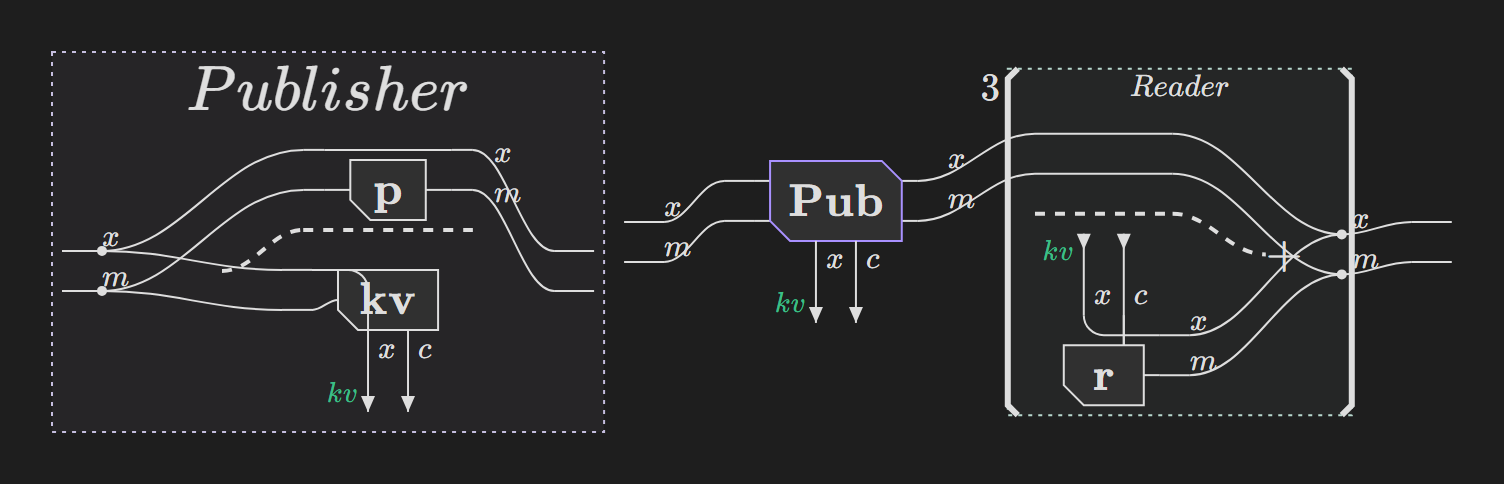

In [21]:
token, width, latent = (cat.RawAxis.named('x'), cat.RawAxis.named('m'),
                        cat.RawAxis.named('c'))
hidden = cat.Array(R, (token, width))
entries = cat.Array(R, (token, latent))
hidden_identity = cat.ProdObject((hidden,)).identity()
entries_identity = cat.ProdObject((entries,)).identity()

publisher = cat.Block.template(
    (0, 0) @ ((token >> ops.Linear.template((width,), (width,), 'p'))
              * (token >> ops.Linear.template((width,), (latent,), 'kv'))),
    title='Publisher', fill_color='#C5BEDF')
reader = ((hidden_identity * (token >> ops.Linear.template((latent,), (width,), 'r')))
          @ ops.AdditionOp.template())
claim(ranks(publisher) == ((2,), (2, 2)) and ranks(reader) == ((2, 2), (2,)),
      'the publisher returns the entries beside the hidden state and the reader takes both')

passenger_layer = cat.Block.template(
    (0, 1, 1) @ (reader * entries_identity),
    title='Reader', fill_color='#B8D8CE', repetition=3)
claim(ranks(passenger_layer) == ((2, 2), (2, 2)),
      'the passenger form carries the published entries across the repetition and '
      'returns them')

kv_slot = fd.DynamicName('kv').capture(Para.TapeSlot())
published = (ops.BlockOperator.template(publisher, 'Pub')
             @ (hidden_identity * Para.Drop(tape=kv_slot, size=entries)))
tape_layer = cat.Block.template(
    (hidden_identity * Para.Grab(tape=kv_slot, size=entries)) @ reader,
    title='Reader', fill_color='#B8D8CE', repetition=3)
plan = published @ tape_layer
claim(ranks(published) == ((2,), (2,)) and ranks(tape_layer) == ((2,), (2,)),
      'the tape form carries the hidden state alone across the repetition')
claim({drop.tape for drop in tutil.type_search(Para.Drop, plan)}
      == {grab.tape for grab in tutil.type_search(Para.Grab, plan)} == {kv_slot},
      'every slot dropped in the plan is grabbed in it')
notebook_listings.print_listing(plan, 'a published value on the tape')
await notebook_diagrams.show_diagram(
    plan,
    'The publisher drops the entries onto the slot and each of the three readers grabs '
    'them, so the repetition carries the hidden state alone.',
    width=700, settings=DIAGRAMS, tape=tape_presentation.TapePresentation.ABSORBED)

### A boxed layer that reads and writes a tape

A `Para.Grab` and a `Para.Drop` have the empty product on one side, so a block holding
them has the domain and the codomain it would have without them, and a plain box over
such a block says nothing about the tape. `ParaBlockOperator` moves the tape onto the
box's own ports: each grab of the body becomes a leading operand and each drop a
trailing result, and the box comes back inside a `ParaWrap` that names the slot standing
at each of those positions. The wrap has the apparent domain and codomain of the block,
which is what the rest of the model composes with, so a reader sees which slots the box
reads and writes without opening the body. Broadcasting the box prepends the degree axes
to the arrays those ports carry and leaves the slots alone.
`obsidian/07-para/Para Block Operator.md` holds the mathematics.

> Rejected: `Para.Drop(tape=slot, size=array)` composed after the boxed layer, with the
> slots the layer touches visible only in the wiring around the box.
> Replacement: the seeds inside the body, with
> `ParaBlockOperator.ParaBlockOperator.template(block, 'Full')` boxing them.

> Rejected: the box with its seeds recorded on the operator alone, whose domain and
> codomain say nothing about the tape.
> Replacement: the grabbed arrays as the box's leading operands and the dropped arrays
> as its trailing results, with the `ParaWrap` over the box naming the slots there.

In [22]:
import para.data_structure.ParaBlockOperator as ParaBlockOperator

GAIN = Para.new_slot()
per_head_value = cat.Array(R, (sequence, head_width))
gained = cat.Block.template(
    (cat.ProdObject((per_head_value,)).identity()
     * Para.Grab(tape=GAIN, size=per_head_value))
    @ lift.morphism_object_lift(ops.AdditionOp.template(),
                                cat.ProdObject((sequence, head_width))),
    title='Gain', fill_color='white')
gain_box = ParaBlockOperator.ParaBlockOperator.template(gained, 'G')
claim(tuple(gain_box.dom()) == tuple(gained.dom())
      and tuple(gain_box.cod()) == tuple(gained.cod()),
      'the wrapped box has the apparent domain and codomain of the block')
claim(tuple(ParaBlockOperator.bare_box_of(gain_box).dom())
      == (per_head_value, per_head_value) and gain_box.grabs == (GAIN, None),
      'the grabbed array is the leading operand of the box, whose slot the wrap names')
claim(ParaBlockOperator.slots_grabbed(gain_box)
      == ParaBlockOperator.slots_grabbed(gained) == frozenset({GAIN}),
      'the slots of a boxed block are read off the wrap as off the body')
per_head_gain = ParaBlockOperator.broadcast_para_block_over_axes(
    gained, (heads,), ((0,),), 'G')
claim(tuple(per_head_gain.dom()) == (cat.Array(R, (heads, sequence, head_width)),),
      'the broadcast box reads the value of every head')
claim(tuple(grab.size for grab in ParaBlockOperator.broadcast_grabs(per_head_gain))
      == (cat.Array(R, (heads, sequence, head_width)),)
      and tuple(grab.tape for grab in ParaBlockOperator.broadcast_grabs(per_head_gain))
      == (GAIN,),
      'broadcasting the box gives the grab the array the degree gives it and leaves the '
      'slot alone')

holds: the wrapped box has the apparent domain and codomain of the block
holds: the grabbed array is the leading operand of the box, whose slot the wrap names
holds: the slots of a boxed block are read off the wrap as off the body
holds: the broadcast box reads the value of every head
holds: broadcasting the box gives the grab the array the degree gives it and leaves the slot alone


## 10. Every size is a free symbol, assigned by name in one configuration

No `Integer` literal appears in a construction. `NumericConfig.template(morphism)`
collects every free size, `assign_values(m=512)` binds them by the body of their name,
and `apply_context` substitutes. Keep the name bodies to a single letter, because
`DynamicName.from_str` splits on `_` and `assign_values` matches on the body, so `k_e`
and `k_x` would collide. An axis minted by an integer size takes the name of whichever
letter alignment later puts at its position, so the `2` in `Linear.template('m', 2)` is
assigned through `h` and `d`.

Two letters in two templates are two axes with two sizes. The `d` of the score signature
and the `d` of the value signature never meet at one position, so the layer holds two
sizes both named `d`, and `assign_values(d=8)` binds both because it matches on the name
body. Name the value width `v` when the two must differ.

In [23]:
config = generate_config.NumericConfig.template(transformer_layer)
size_names = sorted(size.uid._name.body for size in config.terms)
claim(size_names == ['d', 'd', 'f', 'h', 'm', 'x'],
      'the layer has six free sizes, and two of them are named d')
config.assign_values(x=16, m=32, f=64, h=2, d=8)
sized_model = config.apply_context(transformer_layer)
remaining = generate_config.NumericConfig.template(sized_model)
claim(not remaining.terms, 'every size in the layer is now assigned')

holds: the layer has six free sizes, and two of them are named d
holds: every size in the layer is now assigned


## 11. A sized expression compiles to PyTorch

`torch_compile.ConstructedModule.construct(morphism)` builds a `torch.nn.Module` whose
parameters are the weights the `Linear`s hold. Calling it returns one tensor per
codomain wire. An expression without parameters is checked against the same computation
written directly in PyTorch, which is how every validator in the package checks a
construction.

In [24]:
core = scores @ softmax @ weighted
core_config = generate_config.NumericConfig.template(core)
core_config.assign_values(q=5, x=7, d=4, v=3)
sized_core = core_config.apply_context(core)
generator = torch.Generator().manual_seed(1)
q, k, v = (torch.randn(*shape, generator=generator)
           for shape in ((5, 4), (7, 4), (7, 3)))
compiled = torch_compile.ConstructedModule.construct(sized_core)(q, k, v)[0]
reference = (q @ k.T).softmax(dim=-1) @ v
claim(torch.allclose(compiled, reference, atol=1e-6),
      'the compiled attention core matches PyTorch')

module = torch_compile.ConstructedModule.construct(sized_model)
output = module(torch.randn(16, 32, generator=generator))[0]
claim(tuple(output.shape) == (16, 32) and bool(torch.isfinite(output).all()),
      'the transformer layer maps R[x, m] to R[x, m]')

holds: the compiled attention core matches PyTorch
holds: the transformer layer maps R[x, m] to R[x, m]


## 12. A selection hands out values, positions or both

`ds.TopK` keeps the `k` largest entries along one axis and the positions they came from,
and `ds.SelectionForm` names the four ways of handing the two out. `WEIGHTS`, the
default, puts the values on a sparse axis `k/n` with the positions implicit in the axis,
and is the form a model is drawn in. `WEIGHTS_SELECT` puts the values on a dense `k`
beside the positions, which is the pair `torch.topk` returns and what the sparse
expansion produces. `ONLY_WEIGHTS` discards the positions. `ONLY_SELECTION` hands out the
positions alone, as `Nat(n)[k]`.

Write a selection whose values are never read in the `ONLY_SELECTION` form. The positions
say on their own which of the `n` entries are active, so nothing maps the values to one.
Whether the values are read is a fact about the computation, checked against the
reference implementation. A `TopK` followed by $[x > 0]$ reads the sign of each surviving
value and keeps at most `k` entries, those among the top `k` whose value is positive, so it
is the positions form only where the reference reads the positions alone. A payload is
read at the positions by `ds.Select.at_positions`, `[Nat(n); k], [R; n] -> [R; k]`, which has the
selection axis `k` in the target of the positions and of the result, and is broadcast over
everything else. `ds.IndexSelect` computes the same gather with `k` broadcast, and is what
the sparse expansion writes. A selection made among those entries takes the positions as a
second operand, through `positions_of=`, and reports positions of the wider axis. The
candidate pool and the entry selections of
[DeepSeekV41Flash.ipynb](../sota/DeepSeekV41Flash.ipynb)
are the cases.

> Rejected: `ds.TopK.template(axis=P) @ ops.Arithmetic.template(nm.Integer(1))`, a
> selection whose values are replaced by ones so that a `ds.Select` multiplies an
> indicator onto the payload it reads.
> Replacement: `ds.TopK.template(axis=P, form=ds.SelectionForm.ONLY_SELECTION)`, read
> with `ds.IndexSelect`.

> Rejected: `ds.TopK.template(axis=b) @ ops.Arithmetic.template(nm.IsPositive(nm.x))`
> followed by a `ds.Select` on the sparse axis, `(s/b), (b) -> (s/b)`, in
> DeepSeek-V4.1-Flash, whose reference reads every entry its Top-512 returns whatever
> the entry's score.
> Replacement: `ds.TopK.template(axis=b, form=ds.SelectionForm.ONLY_SELECTION)` followed
> by `ds.Select.at_positions(s, b)`, `Nat(b)[s], (b) -> (s)`.

In [26]:
import deepseek.data_structure as ds

scored = cat.RawAxis.named('n')
values_only = ds.TopK.template(axis=scored, name='k/n')
positions_only = ds.TopK.template(axis=scored, name='k/n',
                                  form=ds.SelectionForm.ONLY_SELECTION)
claim(isinstance(values_only.cod()[0].shape()[0], ds.SparseAxis),
      'the WEIGHTS form hands out values on a sparse axis')
claim(isinstance(positions_only.cod()[0].datatype, cat.Natural)
      and not isinstance(positions_only.cod()[0].shape()[0], ds.SparseAxis),
      'the ONLY_SELECTION form hands out positions on a dense axis')
notebook_listings.print_listing(positions_only, 'a selection whose values are not read')

payload = cat.Array(R, (scored,))
selected, = positions_only.cod()[0].shape()
read_at_positions = ((positions_only * cat.ProdObject((payload,)).identity())
                     @ ds.Select.at_positions(selected, scored))
claim(tuple(read_at_positions.cod()) == (cat.Array(R, (selected,)),),
      'a Select at positions hands out the payload along the selection axis')
claim(not list(tutil.type_search(ds.SparseAxis, read_at_positions)),
      'a selection read at its positions holds no sparse axis')
notebook_listings.print_listing(read_at_positions, 'a payload read at the positions')

holds: the WEIGHTS form hands out values on a sparse axis
holds: the ONLY_SELECTION form hands out positions on a dense axis
--- a selection whose values are not read ---
in    %0 : R[n]
out   %1 : Nat[k]
ops   1x TopK
%1 = TopK(%0[{n}]) : Nat[{k}]

holds: a Select at positions hands out the payload along the selection axis
holds: a selection read at its positions holds no sparse axis
--- a payload read at the positions ---
in    %0 : R[n], %1 : R[n]
out   %2 : R[k]
ops   1x Select, 1x TopK
%3 = TopK(%0[{n}]) : Nat[{k}]
%2 = Select(%3[{k}], %1[{n}]) : R[{k}]



## 13. A read outside an axis is empty, and a negative index states causality

A codomain index of a `StrideMorphism` may fall outside `[0, size)` of its axis. The
position read there holds the universal unit, which every fold over an axis ignores and
every elementwise map preserves. Which positions of the array a read leaves empty is an
affine form of the position, and `advanced_axis_dynamics/` derives it.
`mark_sparse_domains.guarded_view` reads each row of its reindexing. Where a row's shift
or a stride is negative, or where a row names its own domain axis in its codomain and
its shift is positive, the row marks the last domain axis it reads as an
`AffineGuards.AffineSparseAxis`, an axis carrying the affine form that says at which
positions it holds a value, guided by the other axes the row reads. The causal window $x' = i_x - i_w$ reads the
token $i_w$ back from the current one and marks its slot axis `w|x`, live where the form
is at least zero, so the slots that would read before the start of the sequence are
empty and the guard arises from the negative stride on the window axis. `ops.View.template` composes the same rows and marks nothing, so a
model asks for the guard by the builder it calls, and a model that reads no axis
outside itself depends on none of this.

A condition that no single read states is written as a relative read, and a merge
carries the result back. A query has reached a compressed entry once it has passed the
entry's last token, which is $i_x - \lvert a \rvert i_b - (\lvert a \rvert - 1) \geq 0$.
The queries are read by group and offset, $i_x = \lvert a \rvert i_{b_0} - i_a + 2 \lvert
a \rvert - 2$, where group $i_{b_0}$ holds the queries whose newest reachable entry is
$i_{b_0}$, and the keys are read at $i_b = i_{b_0} - i_r$, entry $i_r$ back from that
entry, so an unreached entry is a negative index, reads the unit, and marks the slot axis
`r|b0`. The query axis is sized $\lvert a \rvert \lvert b \rvert$, so the newest offsets
of the last group provably read past its end and the same builder marks the offset axis
`a|b0`. A row onto a codomain axis is examined for reading past the end where the axis's
size is written in the row's own symbols, and taken to size the axis where it is not,
which is how a group view or a block split onto a fresh axis marks nothing. An
`aops.CovariantView` with the query row, broadcast over the slots, then writes each score
back to its query. A merge is an injection from its domain box, so a codomain position it
does not write holds the unit, and a broadcast axis guided by an axis the merge consumes
leaves guided by the codomain: `mark_sparse_codomains.mark_sparse_codomain` derives
`r|x`, live where the form above holds with the slot in place of the entry, and the query
axis stays dense because the form on the slots implies the form on the query. The output
holds every entry counted back from the query's newest reachable entry, and a selection
over it hands out distances. No mask operator is written.

Write the part of a reindexing that changes nothing as a `cat.Rearrangement`, a product
with the identity and a composition, and keep only the rows that compute something in
the `StrideMorphism`. The one exception is the row that makes an axis sparse: a view that
reads the dense entry axis and produces the sparse one pairs two different axis objects,
which a rearrangement cannot do, so that row stays a stride row even at unit stride.
`mark_sparse_domains.mark_sparse_domain` marks a composite from its last factor back to
its first. A selection over an axis live on a run from its first position hands its slots
out on an axis live on the same run, `s|x`. A view that reads a sparse axis names it in
its codomain and pulls the form back onto its own domain.
[DeepSeekV41Flash.ipynb](../sota/DeepSeekV41Flash.ipynb)
writes its window, its indexer, its entry gather, its reachable blocks and its selections
this way.

Two axes whose guards differ are concatenated rather than joined into one guard. The
attention core of DeepSeek-V4.1-Flash scores each query against the window slots `w|x`
and against the selected slots `s|x`, and one softmax runs over both.
`aops.ConcatenateAxes` states the concatenation as one stride row per input, each
writing its own axis into a run of the concatenated axis, the runs disjoint and together
filling it. The concatenated axis is an `AxisConcatenation.ConcatenatedAxis`. It
references its parts, its size is the sum of theirs, and it is labelled by them, so the
window slots `w|x` beside the selected slots `s|x` read `w|x + s|x`. Composition
replaces a part by the axis it meets and rebuilds the concatenated axis with it, so a
concatenation written over a raw axis is labelled by the guarded axis a view puts in its
place. The axis carries no form of its own, because its live positions are the union of
two runs under two forms and no single affine form states them.
`concatenation_expansion.expand_concatenations` restores the parts. A consumer that
computes at each position of the concatenated axis on its own is rewritten as $B_F$ of
that consumer applied to each part, where $B_F$ is a concatenation again for a consumer
broadcast over the axis, and the fold `part_combination` declares for a consumer that
folds the axis away. That fold is the accumulator of the fold, read from
`algebra.registries.accumulator`, which is the table a stream loop reads for the partial
result one iteration holds: an addition for a sum or a contraction, and a maximum for a
maximum. Expanding the core written that way gives the two-branch core
`notebooks/sota/DeepSeekV41Flash/scaled_attention_core.py` writes by hand, and
`advanced_axis_dynamics/validate_advanced_axis_dynamics.py` compares the two.

Put the concatenation outside a block computed once per index of a degree. A block
holding it would perform the concatenation once per index, and the parts are one array
at every index, so `discovering_broadcasts.confirm_broadcast_expansion` refuses such a
body against the same expression written out over the degree.
`concatenation_expansion.expand_concatenations_through_blocks` reaches the consumers
inside the body by writing the block out first, which is the rule
$x \mathbin{\vdots} y \gg F = (x \gg F \times y \gg F) \mathbin{;} \mathrm{concat}$
read from the concatenation towards its consumers.

> Rejected: `ops.WeightedTriangularLower`, a mask operator, and a zero-one mask multiplied
> onto the scores, which gives a masked position the weight $e^{0}$.
> Replacement: the negative shift of the window's own row, and for the reachability of an
> entry, the keys read back from the query group's newest reachable entry and a merge
> writing the scores back to the queries.

> Rejected: a `reach` view whose reindexing copied the query, computed the distance
> $i_x - \lvert a \rvert i_b - (\lvert a \rvert - 1)$ onto an axis and deleted that axis.
> The stride category is Cartesian, so a copy, a map on the copy and a deletion compose to
> the identity on the position, and the algebra may erase the row that carried the
> causality. Rejected before it: one `StrideMorphism` with unit-stride rows for the query
> and the entry beside the distance row. Rejected after it: a second row of the merge
> writing the entry $i_{b_0} - i_r$, because the selection reads the slots as they are.
> Replacement: the `grp` and `back` views and the `pos` merge below, each a read or a
> write that no rewrite removes.

> Rejected: the window $x' = i_x + i_w + 1 - \lvert w \rvert$, a positive stride on the
> window axis with the shift $1 - \lvert w \rvert$, whose guard comes from the shift
> falling below zero and whose empty end is therefore `FIRST`.
> Replacement: $x' = i_x - i_w$, which counts the slots back from the current token, so
> that the guard comes from the negative stride and a convolution reads its taps in the
> order a convolution reads them.

> Rejected: one `AffineGuards.AffineSparseAxis` over the window slots and the selected
> slots together, whose live positions would be the union of the two runs.
> Replacement: `aops.ConcatenateAxes` over the two axes, each keeping its own form, and
> the expansion that rewrites every consumer of the concatenation into the consumers of
> the two parts.

In [27]:
import advanced_axis_dynamics.algebra.concatenation_expansion as concatenation_expansion
import advanced_axis_dynamics.algebra.mark_sparse_domains as mark_sparse_domains
import advanced_axis_dynamics.data_structure.AffineGuards as AffineGuards
import advanced_axis_dynamics.data_structure.AxisConcatenation as AxisConcatenation
import agent_display as ad
import advanced_axis_dynamics.data_structure.Operators as aops

slots, channels, entries, offsets = (cat.RawAxis.named(name) for name in 'wcba')
queries = fd.DynamicName('x').capture(
    cat.RawAxis(_size=offsets.local_size() * entries.local_size()))
query_position, position = nm.FreeNumeric.named('i_x'), nm.FreeNumeric.named('j')
window = cat.StrideMorphism(
    _dom=(queries, slots),
    _cod_stride_shift=((queries, (nm.Integer(1), nm.Integer(-1)), nm.Integer(0)),),
    name=fd.DynamicName('win'))
window_view = mark_sparse_domains.guarded_view(
    reindexing=(window, cat.ProdObject((channels,)).identity()), name='win')
slot_axis = window_view.cod()[0].shape()[1]
claim(isinstance(slot_axis, AffineGuards.AffineSparseAxis)
      and slot_axis.guides == (queries,),
      'a row with a negative stride marks the last axis it reads, guided by the other')
claim(slot_axis.guard_form((query_position,), position)
      == nm.collect_like_terms(query_position - position),
      'the window form is i_x - j, so the guard comes from the negative stride on j')
claim(slot_axis.empty_end() is AffineGuards.EmptyEnd.LAST,
      'slot j reads the token j back, so the slots reading before the start of the '
      'sequence are the last ones')
claim(mark_sparse_domains.live_positions(
          slot_axis, (2,), {offsets.local_size(): 2, entries.local_size(): 8,
                            slots.local_size(): 8})
      == [0, 1, 2],
      'query 2 holds a value in the three slots that read tokens 2, 1 and 0')
claim(ops.View.template(
          reindexing=(window, cat.ProdObject((channels,)).identity()),
          name='win').cod()[0].shape()[1] is slots,
      'ops.View.template composes the same rows and marks nothing, so a model asks '
      'for the guard by the builder it calls')
notebook_listings.print_listing(window_view, 'a window view marks its slot axis')

key_channels = cat.RawAxis.named('d')
newest_entry = fd.DynamicName.from_str('b_0').capture(cat.RawAxis(_size=entries.local_size()))
back = fd.DynamicName('r').capture(cat.RawAxis(_size=entries.local_size()))
ratio = offsets.local_size()
query_groups = cat.StrideMorphism(
    _dom=(newest_entry, offsets),
    _cod_stride_shift=((queries, (ratio, nm.Integer(-1)), nm.Integer(2) * ratio - nm.Integer(2)),),
    name=fd.DynamicName('grp'))
entries_back = cat.StrideMorphism(
    _dom=(newest_entry, back),
    _cod_stride_shift=((entries, (nm.Integer(1), nm.Integer(-1)), nm.Integer(0)),),
    name=fd.DynamicName('back'))
read_queries = mark_sparse_domains.guarded_view(
    reindexing=(query_groups, cat.ProdObject((key_channels,)).identity()), name='grp')
read_keys = mark_sparse_domains.guarded_view(
    reindexing=(entries_back, cat.ProdObject((key_channels,)).identity()), name='back')
offset_reach = read_queries.cod()[0].shape()[1]
back_reach = read_keys.cod()[0].shape()[1]
few = {offsets.local_size(): 2, entries.local_size(): 4}
claim(isinstance(offset_reach, AffineGuards.AffineSparseAxis)
      and offset_reach.guides == (newest_entry,)
      and offset_reach.extent == queries.local_size()
      and [mark_sparse_domains.live_positions(offset_reach, (group,), few)
           for group in range(4)]
      == [[0, 1], [0, 1], [0, 1], [1]],
      'the query axis sized |a| |b| marks the offsets: the last group holds one query')
claim(isinstance(back_reach, AffineGuards.AffineSparseAxis)
      and back_reach.guides == (newest_entry,)
      and back_reach.empty_end() is AffineGuards.EmptyEnd.LAST,
      'the keys read back from the newest reachable entry are empty past it')
restore = aops.CovariantView.template(
    query_groups.reconstruct(name=fd.DynamicName('pos')), degree=(back_reach,))
scores = ((read_queries * read_keys)
          @ ops.Einops.template('b0 a d, b0 r d -> b0 a r')
          @ restore)
reachable = scores.cod()[0].shape()[1]
claim(tuple(scores.dom()) == (cat.Array(R, (queries, key_channels)),
                              cat.Array(R, (entries, key_channels)))
      and tuple(scores.cod()) == (cat.Array(R, (queries, reachable)),),
      'the relative reads and the merge score the dense queries against the slots')
claim(tuple(restore.operator.reindexing.cod()) == (queries,)
      and tuple(restore.degree()) == (reachable,),
      'the merge writes the query alone and is broadcast over the slots')
claim(isinstance(reachable, AffineGuards.AffineSparseAxis) and reachable.guides == (queries,)
      and reachable.empty_end() is AffineGuards.EmptyEnd.LAST,
      'the slots leave the merge guided by the query, empty at the end')
claim(reachable.guard_form((query_position,), position)
      == nm.collect_like_terms(query_position - ratio * position - ratio + nm.Integer(1)),
      'the merge states the reachability form i_x - |a| j - (|a| - 1) >= 0 on the slots')
short = {offsets.local_size(): 2, entries.local_size(): 8}
claim(mark_sparse_domains.live_positions(reachable, (0,), short) == []
      and mark_sparse_domains.live_positions(reachable, (5,), short) == [0, 1, 2],
      'query 0 reaches no entry, and query 5 reaches three, counted back from the one ending at token 5')
picks = ds.TopK.template(k=nm.FreeNumeric.named('s'), axis=reachable,
                         form=ds.SelectionForm.ONLY_SELECTION)
picked_slots, = picks.cod()[0].shape()
claim(picked_slots.guard_form((query_position,), position)
      == reachable.guard_form((query_position,), position),
      'a selection over a prefix-live axis fills a prefix of its slots under the same form')
notebook_listings.print_listing(
    scores @ lift.morphism_object_lift(picks, cat.ProdObject((queries,))),
    'the relative indexer, the reachable slots and the distances the selection hands out')

join_slots = aops.ConcatenateAxes.template(
    ((queries, slot_axis), (queries, picked_slots)), name='slots')
all_slots = join_slots.cod()[0].shape()[1]
claim(isinstance(all_slots, AxisConcatenation.ConcatenatedAxis)
      and all_slots.parts == (slot_axis, picked_slots)
      and all_slots.local_size() == slot_axis.local_size() + picked_slots.local_size(),
      'the concatenated axis references its parts and is sized by the sum, and it '
      'carries no form, because the union of two runs under two forms is no one '
      'affine form')
claim(ad.morphism_ir.axis_name(all_slots) == 'w|x + s|x',
      'the concatenated axis is labelled by its parts, the guarded window slots and '
      'the guarded selected slots')
summed = join_slots @ ops.Einops.template('x t -> x')
expanded = concatenation_expansion.expand_concatenations(summed)
claim(sorted(type(root.operator).__name__
             for root in tutil.type_search(cat.Broadcasted, expanded))
      == ['AdditionOp', 'Einops', 'Einops'],
      'the sum over a concatenation is the sum of the sums over the parts, which is '
      'F(Concat(x, y)) = B_F(F(x), F(y))')
notebook_listings.print_listing(
    expanded, 'the concatenation expanded: one fold per part and one addition')

fold_body = cat.Block.template(ops.Einops.template('x t -> x'), title='\\text{Fold}')
per_head_fold = discovering_broadcasts.broadcast_block_over_axes(
    fold_body, (heads,), ((),), name='\\text{Fold}')
through_the_box = concatenation_expansion.expand_concatenations_through_blocks(
    join_slots @ per_head_fold)
claim(sorted(type(root.operator).__name__
             for root in tutil.type_search(cat.Broadcasted, through_the_box))
      == ['AdditionOp', 'Einops', 'Einops', 'View', 'View'],
      'a concatenation outside a block computed once per head reaches the fold inside '
      'it once the block is written out, each part read through the repeat that shares '
      'it between the heads')

holds: a row with a negative stride marks the last axis it reads, guided by the other
holds: the window form is i_x - j, so the guard comes from the negative stride on j
holds: slot j reads the token j back, so the slots reading before the start of the sequence are the last ones
holds: query 2 holds a value in the three slots that read tokens 2, 1 and 0
holds: ops.View.template composes the same rows and marks nothing, so a model asks for the guard by the builder it calls
--- a window view marks its slot axis ---
in    %0 : R[x, c]
out   %1 : R[x, w|x, c]
ops   1x View
%1 = View<win>(%0[x, c]) : R[x, w|x, c]   via win

holds: the query axis sized |a| |b| marks the offsets: the last group holds one query
holds: the keys read back from the newest reachable entry are empty past it
holds: the relative reads and the merge score the dense queries against the slots
holds: the merge writes the query alone and is broadcast over the slots
holds: the slots leave the merge guided by the query, emp

holds: the sum over a concatenation is the sum of the sums over the parts, which is F(Concat(x, y)) = B_F(F(x), F(y))
--- the concatenation expanded: one fold per part and one addition ---
in    %0 : R[x, w|x], %1 : R[x, s|x]
out   %2 : R[x]
ops   1x AdditionOp, 2x Einops
%3 = Einops(%0[x, {w|x}]) : R[x]
%4 = Einops(%1[x, {s|x}]) : R[x]
%2 = AdditionOp<+>(%3[x], %4[x]) : R[x]

holds: a concatenation outside a block computed once per head reaches the fold inside it once the block is written out, each part read through the repeat that shares it between the heads


### Cutting two axes is one group view per axis

A pixel unshuffle reads a grid of patches as a grid of cells, each cell three patches high and three wide. Its row over the patch rows is $i_{H} = \lvert U \rvert i_{H'} + i_{U}$, its row over the patch columns is $i_{W} = \lvert V \rvert i_{W'} + i_{V}$, and the features are read unchanged. One `StrideMorphism` with three rows over a domain of five positions states the same map, and states it as one table whose strides a reader has to pick apart. The product of one group view per grid axis and the identity on the features states it as three morphisms, each drawn with its own strides, so the figure shows the cut of the rows beside the cut of the columns.

The product hands a cell out as `(H', U, W', V, M)`, because a product places each factor's domain in turn. A rearrangement before it brings the two cell indices to the front, which leaves the target `(U, V, M)`, and that order is the order the projector's weight reads.

> Rejected: `_dom=(H', W', M, U, V)` with three rows onto `(H, W, M)`, and
> `ops.Linear.template((M, U, V), (m,), 'W^{A1}')` after it.
> Replacement: a rearrangement composed with `rows * columns * id_M`, and
> `ops.Linear.template((U, V, M), (m,), 'W^{A1}')`.


In [ ]:
cell_rows, cell_columns, features, row_offsets, column_offsets = (
    cat.RawAxis.named(name) for name in ("H'", "W'", 'M', 'U', 'V'))
patch_rows = fd.DynamicName('H').capture(
    cat.RawAxis(_size=row_offsets.local_size() * cell_rows.local_size()))
patch_columns = fd.DynamicName('W').capture(
    cat.RawAxis(_size=column_offsets.local_size() * cell_columns.local_size()))


def group_view(cells, offset, patches):
    return cat.StrideMorphism(
        _dom=(cells, offset),
        _cod_stride_shift=(
            (patches, (offset.local_size(), nm.Integer(1)), nm.Integer(0)),),
        name=fd.DynamicName('grp'))


cut_rows = group_view(cell_rows, row_offsets, patch_rows)
cut_columns = group_view(cell_columns, column_offsets, patch_columns)
cells_to_the_front = cat.Rearrangement(
    (0, 2, 1, 3, 4),
    (cell_rows, cell_columns, row_offsets, column_offsets, features))
unshuffle = cells_to_the_front @ (
    cut_rows * cut_columns * cat.ProdObject((features,)).identity())
cell_view = ops.View.template(reindexing=(unshuffle,), name='\\mathrm{cell}')
claim(tuple(unshuffle.dom())
      == (cell_rows, cell_columns, row_offsets, column_offsets, features)
      and tuple(unshuffle.cod()) == (patch_rows, patch_columns, features),
      'the rearrangement and the product read two cell indices, two offsets and a '
      'feature and give a patch row, a patch column and a feature')
claim(tuple(cell_view.dom()) == (cat.Array(R, (patch_rows, patch_columns, features)),)
      and tuple(cell_view.cod()) == (cat.Array(
          R, (cell_rows, cell_columns, row_offsets, column_offsets, features)),),
      'the view hands a cell out with its two indices first and the feature last')
claim([stride.name.to_bodies()
       for stride in tutil.type_search(cat.StrideMorphism, unshuffle)] == ['grp', 'grp'],
      'each cut is a named stride morphism of its own, which an inspection box explains')
projected = cell_view @ lift.morphism_object_lift(
    ops.Linear.template((row_offsets, column_offsets, features), (channels,),
                        'W^{A1}'),
    cat.ProdObject((cell_rows, cell_columns)))
claim(tuple(projected.cod()) == (cat.Array(R, (cell_rows, cell_columns, channels)),),
      'the weight reads the two offsets and the feature of a cell, in the order the '
      'product leaves them in')
notebook_listings.print_listing(projected, 'the pixel unshuffle and the projector')


### A fixed one-hot is a covariant read with no operands

Every reindexing is a linear map. A row with an empty domain and the shift $i_x$ sends
the one index of the empty product to position $i_x$ of its codomain axis, so an
`ops.View` of it, which reads a reindexing contravariantly, selects position $i_x$ of
the array it reads. Read covariantly the same row writes its operand at position $i_x$
and leaves every other position holding the universal unit, which is the one-hot vector
at that position. An `aops.CovariantView` of the row with no operands and a backup
degree is therefore the constant one-hot array, and no opaque operator is needed for
one. `aops.CovariantView.template` cannot build it, because it asks
`mark_sparse_codomains.merge_groups` for a bijection between the two index boxes and an
injection out of the empty product is not one, so the `cat.Broadcasted` is written
directly, as a parameter array is.

> Rejected: `custom('A^{0}', (), ((x, n),))`, a nullary `GenericOperator` over the
> positions and the streams, which is the form DeepSeek-V4.1-Flash's initial collapse
> vector had until 2026-09-15.
> Replacement: a `cat.Broadcasted` over `aops.CovariantView` of the row
> `_dom=(), _cod_stride_shift=((n, (), 0),)`, with no input weaves and
> `backup_degree=(x,)`.

In [28]:
import advanced_axis_dynamics.algebra.mark_sparse_codomains as mark_sparse_codomains

streams = cat.RawAxis.named('n')
first_stream = cat.StrideMorphism(
    _dom=(), _cod_stride_shift=((streams, (), nm.Integer(0)),),
    name=fd.DynamicName('A^{0}'))
one_hot = cat.Broadcasted(
    operator=aops.CovariantView(name=fd.DynamicName('A^{0}'),
                                reindexing=first_stream),
    output_weaves=(cat.Weave(R, (cat.WeaveMode.TILED, streams)),),
    backup_degree=cat.ProdObject((queries,)))
claim(not tuple(one_hot.dom())
      and tuple(one_hot.cod()) == (cat.Array(R, (queries, streams)),),
      'the one-hot reads nothing and writes one vector per query')
claim(tuple(one_hot.degree()) == (queries,),
      'a morphism with an empty domain carries its degree in backup_degree')
selects_the_first = ops.View.template(reindexing=first_stream)
claim(tuple(selects_the_first.dom()) == (cat.Array(R, (streams,)),)
      and tuple(selects_the_first.cod()) == (cat.Array(R, ()),),
      'the same row read contravariantly selects the first stream')
try:
    aops.CovariantView.template(first_stream, degree=(queries,))
    states_the_injection = True
except mark_sparse_codomains.NotAMixedRadixSplit:
    states_the_injection = False
claim(not states_the_injection,
      'the template asks for a bijection, and an injection out of the empty product is '
      'none')
notebook_listings.print_listing(one_hot, 'the one-hot the first sublayer collapses with')

holds: the one-hot reads nothing and writes one vector per query
holds: a morphism with an empty domain carries its degree in backup_degree
holds: the same row read contravariantly selects the first stream
holds: the template asks for a bijection, and an injection out of the empty product is none
--- the one-hot the first sublayer collapses with ---
in    (none)
out   %0 : R[x, n]
ops   1x CovariantView
%0 = CovariantView<A^{0}>() : R[x, {n}]



## 14. A definition states that an operator equals an expression

A `cat.DefinedExpression` has a `left_hand_side` and a `right_hand_side`, which are two morphisms with one domain and one codomain, and a figure draws the two with $:=$ between them. `cat.DefinedExpression.template` raises `cat.SidesOfADefinitionDisagree` where the two sides differ in their domain or their codomain. A definition is a term that is drawn and is never composed. The rules below use it twice, for an operator and its expansion and for an operator whose value depends on an index.

An axis cut into the parts that fill it is a deconcatenation. `aops.DeconcatenateAxes` holds the part reindexings that an `aops.ConcatenateAxes` of the same parts holds. The reverse derivative of each is the other. The standard expansion of a deconcatenation is a copy of the input followed by one `ops.View` for each part, and `define_by_expansion.define_by_standard_expansion` pairs the operator with that expansion.

> Rejected: `ops.View.template(reindexing=(tail,))`, the affine read of the last channels of a latent at a shift, which leaves the other channels on a second read that no operator states.
> Replacement: `aops.DeconcatenateAxes.template(((unrotated,), (rotated,)), concatenated=latent)`, with the first part declared at the size $\lvert c \rvert - \lvert z \rvert$.

Reals that are rotated in pairs are complex numbers. `dst.PairsAsComplex` reads $R[z]$ as $\mathbb{C}\langle R \rangle[t]$ with $\lvert z \rvert = 2 \lvert t \rvert$, a rotation through the angle $\phi$ is the product with $e^{\mathrm{i} \phi}$, and `dst.Decomplex` writes the pairs back as reals.

An operator whose value depends on an index is no broadcast operator, because a broadcast operator is one function at every index of its degree. It is a `GenericOperator` that consumes the axis, and a definition gives it its meaning. The right-hand side of the definition needs the index as a value. The subsection below states how an `ops.Arrange` supplies the index, so that both sides of the definition are written over every position and neither reads one position.

> Rejected: a `GenericOperator` with no operands for the YaRN ramp $R[t]$, with its dependence on the pair stated in prose alone.
> Replacement: $r := \ulcorner (\mathrm{arrange}_t - \ell) / (u - \ell) \lrcorner$ as a `cat.DefinedExpression`, which the subsection below builds.

holds: a deconcatenation cuts one declared axis into the parts that fill it
holds: a concatenation and a deconcatenation of the same parts are each the reverse derivative of the other
holds: the standard expansion of a deconcatenation reads each part through one View
holds: the two sides of a definition have one domain and one codomain
A deconcatenation is defined as a copy of its input followed by one affine view for each part.


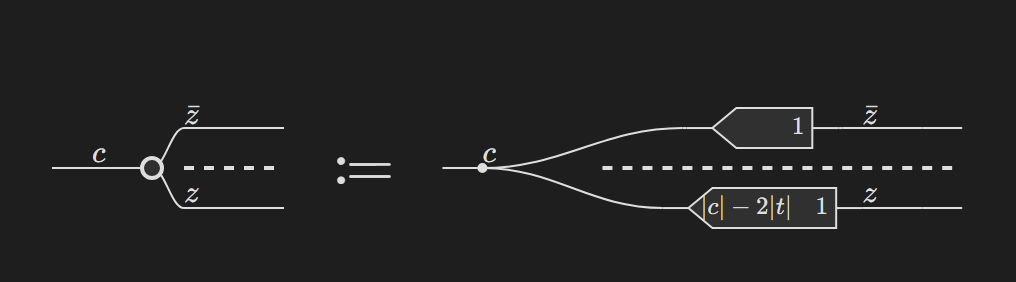

holds: an operator whose value differs at every pair holds the pair axis in its target


In [29]:
import advanced_axis_dynamics.registries.derivative  # noqa: F401 - the reverse rules
import advanced_axis_dynamics.registries.standard_expansions  # noqa: F401 - the deconcatenation's rule
import algebra.define_by_expansion as define_by_expansion
import deepseek.data_structure as dst
import para.registries.derivative as derivative

latent, pairs = cat.RawAxis.named('c'), cat.RawAxis.named('t')
rotated = fd.DynamicName('z').capture(cat.RawAxis(_size=nm.Integer(2) * pairs.local_size()))
unrotated = fd.DynamicName('\\bar{z}').capture(
    cat.RawAxis(_size=latent.local_size() - rotated.local_size()))
cut = aops.DeconcatenateAxes.template(((unrotated,), (rotated,)), concatenated=latent)
claim(tuple(cut.dom()) == (cat.Array(R, (latent,)),)
      and tuple(cut.cod()) == (cat.Array(R, (unrotated,)), cat.Array(R, (rotated,))),
      'a deconcatenation cuts one declared axis into the parts that fill it')
_, joined = derivative.rule_for(cut.operator)(cut)
_, cut_again = derivative.rule_for(joined.operator)(joined)
claim(isinstance(joined.operator, aops.ConcatenateAxes)
      and isinstance(cut_again.operator, aops.DeconcatenateAxes)
      and cut_again.operator.part_reindexings == cut.operator.part_reindexings,
      'a concatenation and a deconcatenation of the same parts are each the reverse '
      'derivative of the other')
cut_defined = define_by_expansion.define_by_standard_expansion(cut)
claim(sum(isinstance(node.operator, ops.View)
          for node in tutil.type_search(cat.Broadcasted, cut_defined.right_hand_side)) == 2,
      'the standard expansion of a deconcatenation reads each part through one View')
try:
    cat.DefinedExpression.template(cut, joined)
    sides_may_disagree = True
except cat.SidesOfADefinitionDisagree:
    sides_may_disagree = False
claim(not sides_may_disagree,
      'the two sides of a definition have one domain and one codomain')
await show(cut_defined, 'A deconcatenation is defined as a copy of its input followed '
           'by one affine view for each part.', width=900)

value_of_every_pair = cat.Array(R, (pairs,))
ramp = cat.Broadcasted(
    operator=ops.GenericOperator(name=fd.DynamicName('r')),
    input_weaves=(), output_weaves=(cat.Weave(R, (pairs,)),), reindexings=())
claim(tuple(ramp.output_weaves[0].target().shape()) == (pairs,),
      'an operator whose value differs at every pair holds the pair axis in its '
      'target')


### A value proportional to a position is a product with an `Arrange`

An `ops.Arrange` over the axis $x$ has no operands and returns $\mathrm{Nat}(x)[x]$, the array that holds $i_x$ at index $i_x$. The axis stands in the target of the output weave, because a tiled operator is one function at every index of its degree and an `Arrange` writes a different value at every position. A value that is proportional to a position is the product of that array and a factor. The operands of the product carry two datatypes, a natural number and a real, and `ops.Einops.template` gives one datatype to every weave, so `ops.multiply_by_positions` writes the weaves out.

The angle of a rotary embedding is such a product. The exponential of the angle is then one `ops.Arithmetic` from the reals to the complex numbers whose formula holds no index, and the rotation is defined over every token, with no read of one position.

> Rejected: an `ops.Arithmetic` with the formula $e^{\mathrm{i}\, i_x x}$, where $i_x$ is a free numeric, on the right-hand side of a definition at the index $i_x$.
> Replacement: `(ops.Arrange.template(tokens) * frequencies) @ ops.multiply_by_positions(positions, frequencies)`, followed by the `ops.Arithmetic` of $e^{\mathrm{i} x}$.

A formula in a position is an `ops.Arithmetic` applied to the `Arrange`. `ops.Arithmetic.template` reads the datatype of its operand from `base` and takes the datatype of its result as `output_datatype`, so the formula reads a natural number and returns a real, and it holds no free index. The YaRN ramp is one such formula, the clamp of $(x - \ell) / (u - \ell)$. The pair axis of the ramp is the axis the indices are arranged over, and the formula is broadcast over it.

> Rejected: $r[i_t] := \ulcorner (i_t - \ell) / (u - \ell) \lrcorner$, a definition at the index $i_t$ whose left-hand side reads one position of the ramp and whose right-hand side is an `ops.ConstantOp` holding the free numeric $i_t$.
> Replacement: `ops.Arrange.template(pairs) @ ops.Arithmetic.template(nm.Clamp((nm.x - start) / (end - start)), base=positions, output_datatype=R)`.

Two formulas that read the index of one axis share one `Arrange`, whose result is copied. The YaRN frequencies are the power of the base times a formula of the ramp, and the power and the ramp both read the index of the pair.

> Rejected: an `ops.Arithmetic` named $(1 - x + x / s)\, \beta^{-2 i_t / \lvert z \rvert}$, whose formula holds the free numeric $i_t$, and one `ops.Arrange` for each formula that reads the index.
> Replacement: `ops.Arrange.template(pairs) @ cat.Rearrangement((0, 0), (positions,))`, followed by the `ops.Arithmetic` of $\beta^{-2 x / \lvert z \rvert}$ beside the ramp's formula and the `ops.Arithmetic` of $1 - x + x / s$, and their product.


holds: an Arrange has no operands and returns the indices of its axis over that axis
holds: the axis stands in the target, and the operator is named after the index it holds
holds: the product of the positions and a real array reads two datatypes and returns reals over both axes
holds: an Arithmetic reads one datatype and returns another where output_datatype names it
holds: the formula of the exponential holds no index, because the position arrives as a value
holds: the definition of the rotation reads no single position of the token axis
A rotation is defined over every token as a product with the complex exponential of the position times the frequency.


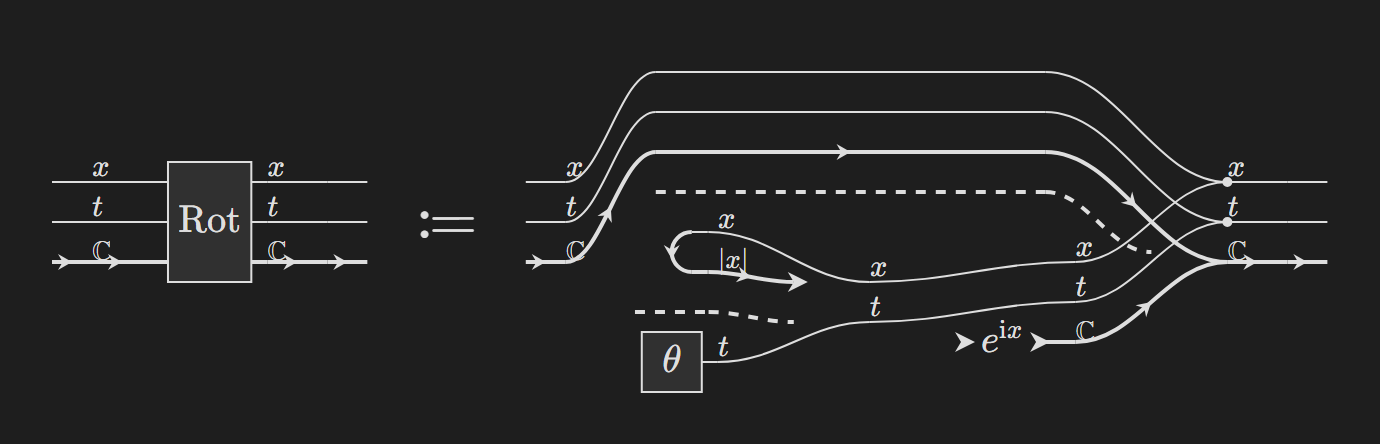

holds: a formula applied to an Arrange reads a natural number and returns a real, broadcast over the axis the indices are arranged over
holds: the definition of the ramp reads no single position of the pair axis
The YaRN ramp is the clamp to the interval from 0 to 1, applied to the index of every pair.


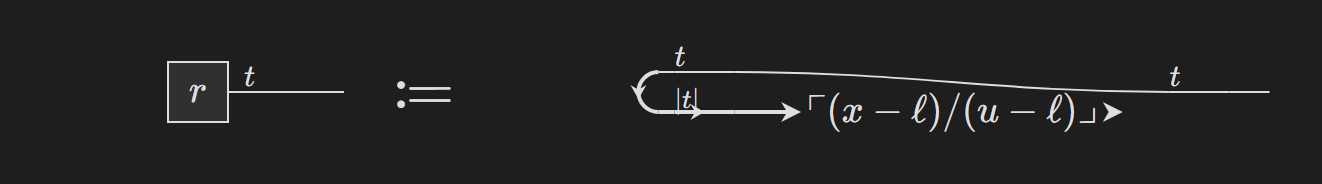

holds: the power of the base reads a natural number and returns a real
holds: the two formulas that read the index of the pair share one Arrange
holds: no formula of the frequencies holds the index of the pair
The YaRN frequencies are the power of the base times a formula of the ramp, and one Arrange over the pairs feeds both.


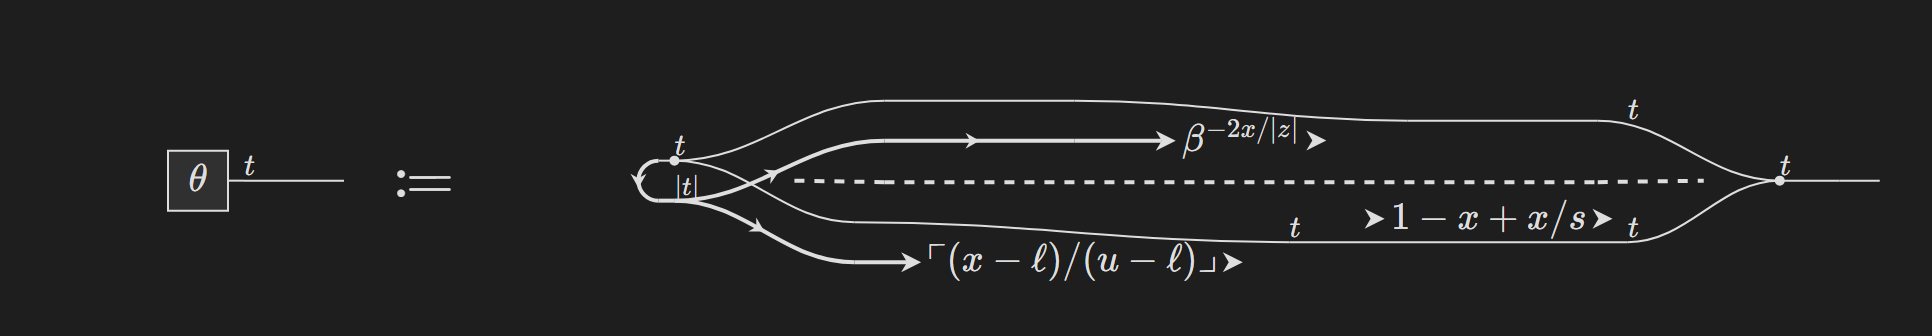

In [30]:
tokens = cat.RawAxis.named('x')
complex_reals = dst.Complex(R)
positions = ops.Arrange.template(tokens)
position_of_every_token = cat.Array(cat.Natural(tokens.local_size()), (tokens,))
claim(positions.has_empty_domain()
      and tuple(positions.cod()) == (position_of_every_token,),
      'an Arrange has no operands and returns the indices of its axis over that axis')
claim(tuple(positions.degree()) == ()
      and positions.operator.name.to_latex() == 'i_x',
      'the axis stands in the target, and the operator is named after the index it '
      'holds')
angles = ops.multiply_by_positions(position_of_every_token, value_of_every_pair)
claim([weave.datatype for weave in angles.input_weaves]
      == [cat.Natural(tokens.local_size()), R]
      and tuple(angles.cod()) == (cat.Array(R, (tokens, pairs)),),
      'the product of the positions and a real array reads two datatypes and returns '
      'reals over both axes')

frequencies = cat.Broadcasted(
    operator=ops.GenericOperator(name=fd.DynamicName('\\theta')),
    input_weaves=(), output_weaves=(cat.Weave(R, (pairs,)),), reindexings=())
exponential_of_the_angle = ops.Arithmetic.template(
    nm.Power.template(
        nm.Constant(), nm.Constant(nm.ConstantSymbol.IMAGINARY_UNIT) * nm.x),
    base=cat.Array(R, (tokens, pairs)), output_datatype=complex_reals)
claim(exponential_of_the_angle.input_weaves[0].datatype == R
      and exponential_of_the_angle.output_weaves[0].datatype == complex_reals,
      'an Arithmetic reads one datatype and returns another where output_datatype '
      'names it')
pairs_of_every_token = cat.Array(complex_reals, (tokens, pairs))
rotation = cat.Broadcasted(
    operator=ops.GenericOperator(name=fd.DynamicName('\\mathrm{Rot}')),
    input_weaves=(cat.Weave(complex_reals, (tokens, pairs)),),
    output_weaves=(cat.Weave(complex_reals, (tokens, pairs)),),
    reindexings=(cat.ProdObject().identity(),))
rotation_defined = cat.DefinedExpression.template(
    rotation,
    (hold(pairs_of_every_token)
     * ((positions * frequencies) @ angles @ exponential_of_the_angle))
    @ ops.Einops.template('x t, x t -> x t', datatype=complex_reals))
claim(not list(tutil.type_search(nm.FreeNumeric, exponential_of_the_angle.operator)),
      'the formula of the exponential holds no index, because the position arrives as '
      'a value')
claim(not [row for row in tutil.type_search(
               cat.StrideMorphism, rotation_defined.right_hand_side)
           if row._dom == () and len(row._cod_stride_shift) == 1],
      'the definition of the rotation reads no single position of the token axis')
await show(rotation_defined, 'A rotation is defined over every token as a product with '
           'the complex exponential of the position times the frequency.', width=1200)

rotary_base, yarn_factor = nm.FreeNumeric.named('\\beta'), nm.FreeNumeric.named('s')
position_of_every_pair = cat.Array(cat.Natural(pairs.local_size()), (pairs,))
power_of_the_base = ops.Arithmetic.template(
    nm.Power.template(rotary_base, nm.Integer(-2) * nm.x / rotated.local_size()),
    base=position_of_every_pair, output_datatype=R,
    name='\\beta^{-2 x / \\lvert z \\rvert}')
interpolation_along_the_ramp = ops.Arithmetic.template(
    1 - nm.x + nm.x / yarn_factor, base=value_of_every_pair, name='1 - x + x / s')
ramp_start, ramp_end = nm.FreeNumeric.named('\\ell'), nm.FreeNumeric.named('u')
clamp_of_the_pair_index = ops.Arithmetic.template(
    nm.Clamp((nm.x - ramp_start) / (ramp_end - ramp_start)),
    base=position_of_every_pair, output_datatype=R,
    name='\\ulcorner (x - \\ell) / (u - \\ell) \\lrcorner')
ramp_defined = cat.DefinedExpression.template(
    ramp, ops.Arrange.template(pairs) @ clamp_of_the_pair_index)
claim(clamp_of_the_pair_index.input_weaves[0].datatype
      == cat.Natural(pairs.local_size())
      and clamp_of_the_pair_index.output_weaves[0].datatype == R
      and tuple(clamp_of_the_pair_index.degree()) == (pairs,),
      'a formula applied to an Arrange reads a natural number and returns a real, '
      'broadcast over the axis the indices are arranged over')
claim(not [row for row in tutil.type_search(cat.StrideMorphism, ramp_defined)
           if row._dom == () and len(row._cod_stride_shift) == 1],
      'the definition of the ramp reads no single position of the pair axis')
await show(ramp_defined, 'The YaRN ramp is the clamp to the interval from 0 to 1, '
           'applied to the index of every pair.', width=1400)

frequencies_defined = cat.DefinedExpression.template(
    frequencies,
    ops.Arrange.template(pairs)
    @ cat.Rearrangement((0, 0), (position_of_every_pair,))
    @ (power_of_the_base
       * (clamp_of_the_pair_index @ interpolation_along_the_ramp))
    @ ops.Einops.template('t, t -> t'))
claim(power_of_the_base.input_weaves[0].datatype == cat.Natural(pairs.local_size())
      and power_of_the_base.output_weaves[0].datatype == R,
      'the power of the base reads a natural number and returns a real')
claim(sum(isinstance(node.operator, ops.Arrange) for node in tutil.type_search(
          cat.Broadcasted, frequencies_defined.right_hand_side)) == 1,
      'the two formulas that read the index of the pair share one Arrange')
claim(nm.FreeNumeric.named('i_t') not in set(tutil.type_search(
          nm.FreeNumeric, frequencies_defined.right_hand_side)),
      'no formula of the frequencies holds the index of the pair')
await show(frequencies_defined, 'The YaRN frequencies are the power of the base '
           'times a formula of the ramp, and one Arrange over the pairs feeds both.',
           width=1400)


## Where to go next

- [DeepSeekV41Flash.ipynb](../sota/DeepSeekV41Flash.ipynb):
  a whole published architecture, drawn through `BlockOperator` and given the
  quantisations of the released code.
- [Representing Models](../../obsidian/06-practice/Representing%20Models.md): the
  rules for a published architecture, with the failure each one prevents.